<a href="https://colab.research.google.com/github/ChewWJ1/ML-dating-app-behaviour/blob/main/ML_dating_app_behaviour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💘 Tying the Data Knot: Predicting Meaningful Connections
### WIA1006/WID3006 Machine Learning — Group Assignment
**Sem 2, Session 2025/2026 | FCSIT, Universiti Malaya**

---
**Project Goal:** Predict whether a dating app user will achieve a **meaningful connection**
(Mutual Match, Instant Match, Date Happened, or Relationship Formed)
based on their demographic profile and in-app behaviour.

**Task Type:** Binary Classification (`match_outcome` → Positive / Negative)

**Dataset:** `dating_app_behavior_dataset_extended1.csv` — 50,000 records × 25 features

---
## 📦 Section 1: Install & Import Libraries

In [ ]:
# Install required packages (run once in Colab)
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Plot style
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

RANDOM_STATE = 42
print('Libraries loaded successfully')

Libraries loaded successfully


---
## 📂 Section 2: Data Loading

In [ ]:
# ------------------------------------------------------------------
# Dataset Path Setup (Local)
# ------------------------------------------------------------------
DATA_PATH = 'dating_app_behavior_dataset_extended1.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head()

Dataset loaded: 50,000 rows x 25 columns


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,...,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome,age,height_cm,weight_kg,zodiac_sign,body_type,relationship_intent
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,...,0.36,13,Early Morning,Mutual Match,56,149,40.6,Taurus,Curvy,Friends Only
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,...,0.42,0,Morning,Chat Ignored,40,155,69.7,Leo,Plus Size,Hookups
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,...,0.41,1,After Midnight,Date Happened,30,185,96.9,Sagittarius,Curvy,Serious Relationship
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,...,0.07,21,Morning,No Action,57,154,49.3,Taurus,Slim,Exploring
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,...,0.11,22,After Midnight,One-sided Like,24,149,40.0,Libra,Slim,Casual Dating


In [ ]:
# Quick column overview
print('Column names and dtypes:')
for col in df_raw.columns:
    print(f'  {col:<30} dtype={df_raw[col].dtype}')

Column names and dtypes:
  gender                         dtype=str
  sexual_orientation             dtype=str
  location_type                  dtype=str
  income_bracket                 dtype=str
  education_level                dtype=str
  interest_tags                  dtype=str
  app_usage_time_min             dtype=int64
  app_usage_time_label           dtype=str
  swipe_right_ratio              dtype=float64
  swipe_right_label              dtype=str
  likes_received                 dtype=int64
  mutual_matches                 dtype=int64
  profile_pics_count             dtype=int64
  bio_length                     dtype=int64
  message_sent_count             dtype=int64
  emoji_usage_rate               dtype=float64
  last_active_hour               dtype=int64
  swipe_time_of_day              dtype=str
  match_outcome                  dtype=str
  age                            dtype=int64
  height_cm                      dtype=int64
  weight_kg                      dtype=float64

---
## 🔍 Section 3: Exploratory Data Analysis (EDA)

### 3.1 Basic Info & Statistics

In [ ]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  str    
 1   sexual_orientation    50000 non-null  str    
 2   location_type         50000 non-null  str    
 3   income_bracket        50000 non-null  str    
 4   education_level       50000 non-null  str    
 5   interest_tags         50000 non-null  str    
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  str    
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  str    
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 15  emoji_usage_rate      50000 no

In [ ]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,50000,6,Female,8384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexual_orientation,50000,8,Straight,6326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_type,50000,6,Remote Area,8519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_bracket,50000,7,High,7309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,50000,9,Bachelor’s,5646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
interest_tags,50000,40206,"Fitness, Anime, Yoga",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_usage_time_min,50000.0,NaN,NaN,NaN,149.9124,86.990521,0.0,74.0,150.0,225.0,300.0
app_usage_time_label,50000,7,Extreme User,20140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
swipe_right_ratio,50000.0,NaN,NaN,NaN,0.500655,0.197468,0.0,0.37,0.5,0.64,1.0
swipe_right_label,50000,4,Optimistic,26873,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Missing Values & Duplicates

In [ ]:
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found')

dups = df_raw.duplicated().sum()
print(f'\nDuplicate rows: {dups}')

Missing values per column:
No missing values found

Duplicate rows: 0


### 3.3 Target Variable — match_outcome

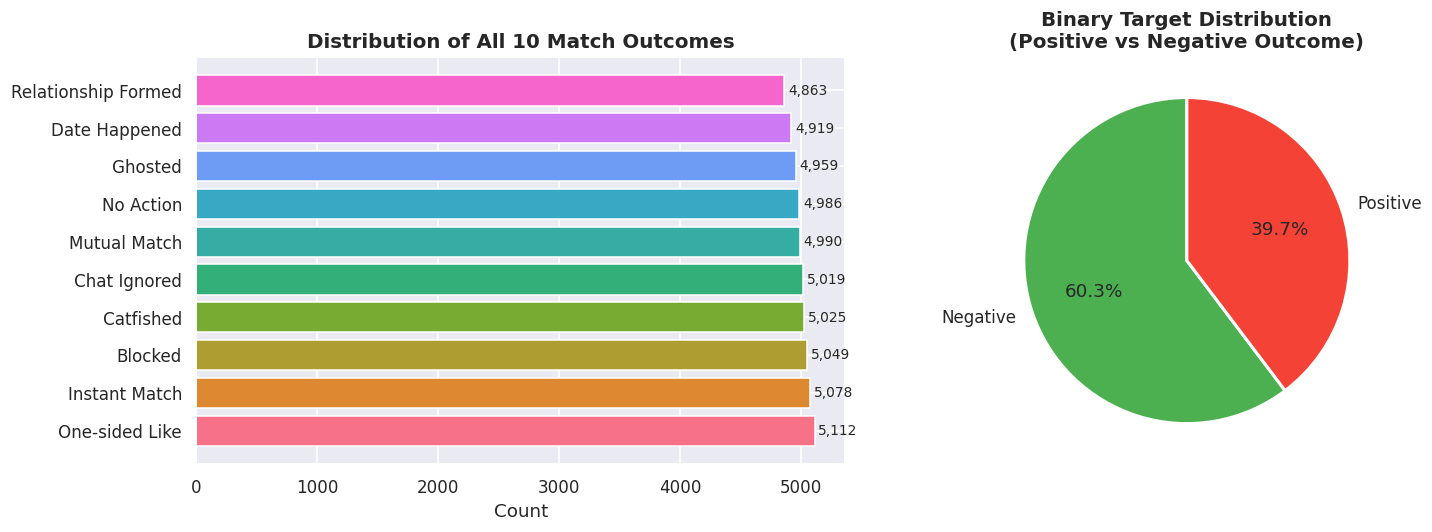

Positive (meaningful connection):    19,850 (39.7%)
Negative (no meaningful connection): 30,150 (60.3%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All 10 classes
counts = df_raw['match_outcome'].value_counts()
colors = sns.color_palette('husl', len(counts))
axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_title('Distribution of All 10 Match Outcomes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(v + 30, i, f'{v:,}', va='center', fontsize=9)

# Binary target
positive_outcomes_eda = {'Mutual Match', 'Instant Match', 'Date Happened', 'Relationship Formed'}
binary_labels = df_raw['match_outcome'].apply(
    lambda x: 'Positive' if x in positive_outcomes_eda else 'Negative'
)
binary_counts = binary_labels.value_counts()
axes[1].pie(binary_counts.values, labels=binary_counts.index,
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Binary Target Distribution\n(Positive vs Negative Outcome)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Positive (meaningful connection):    {binary_counts["Positive"]:,} ({binary_counts["Positive"]/len(df_raw)*100:.1f}%)')
print(f'Negative (no meaningful connection): {binary_counts["Negative"]:,} ({binary_counts["Negative"]/len(df_raw)*100:.1f}%)')

### 3.4 Categorical Feature Distributions

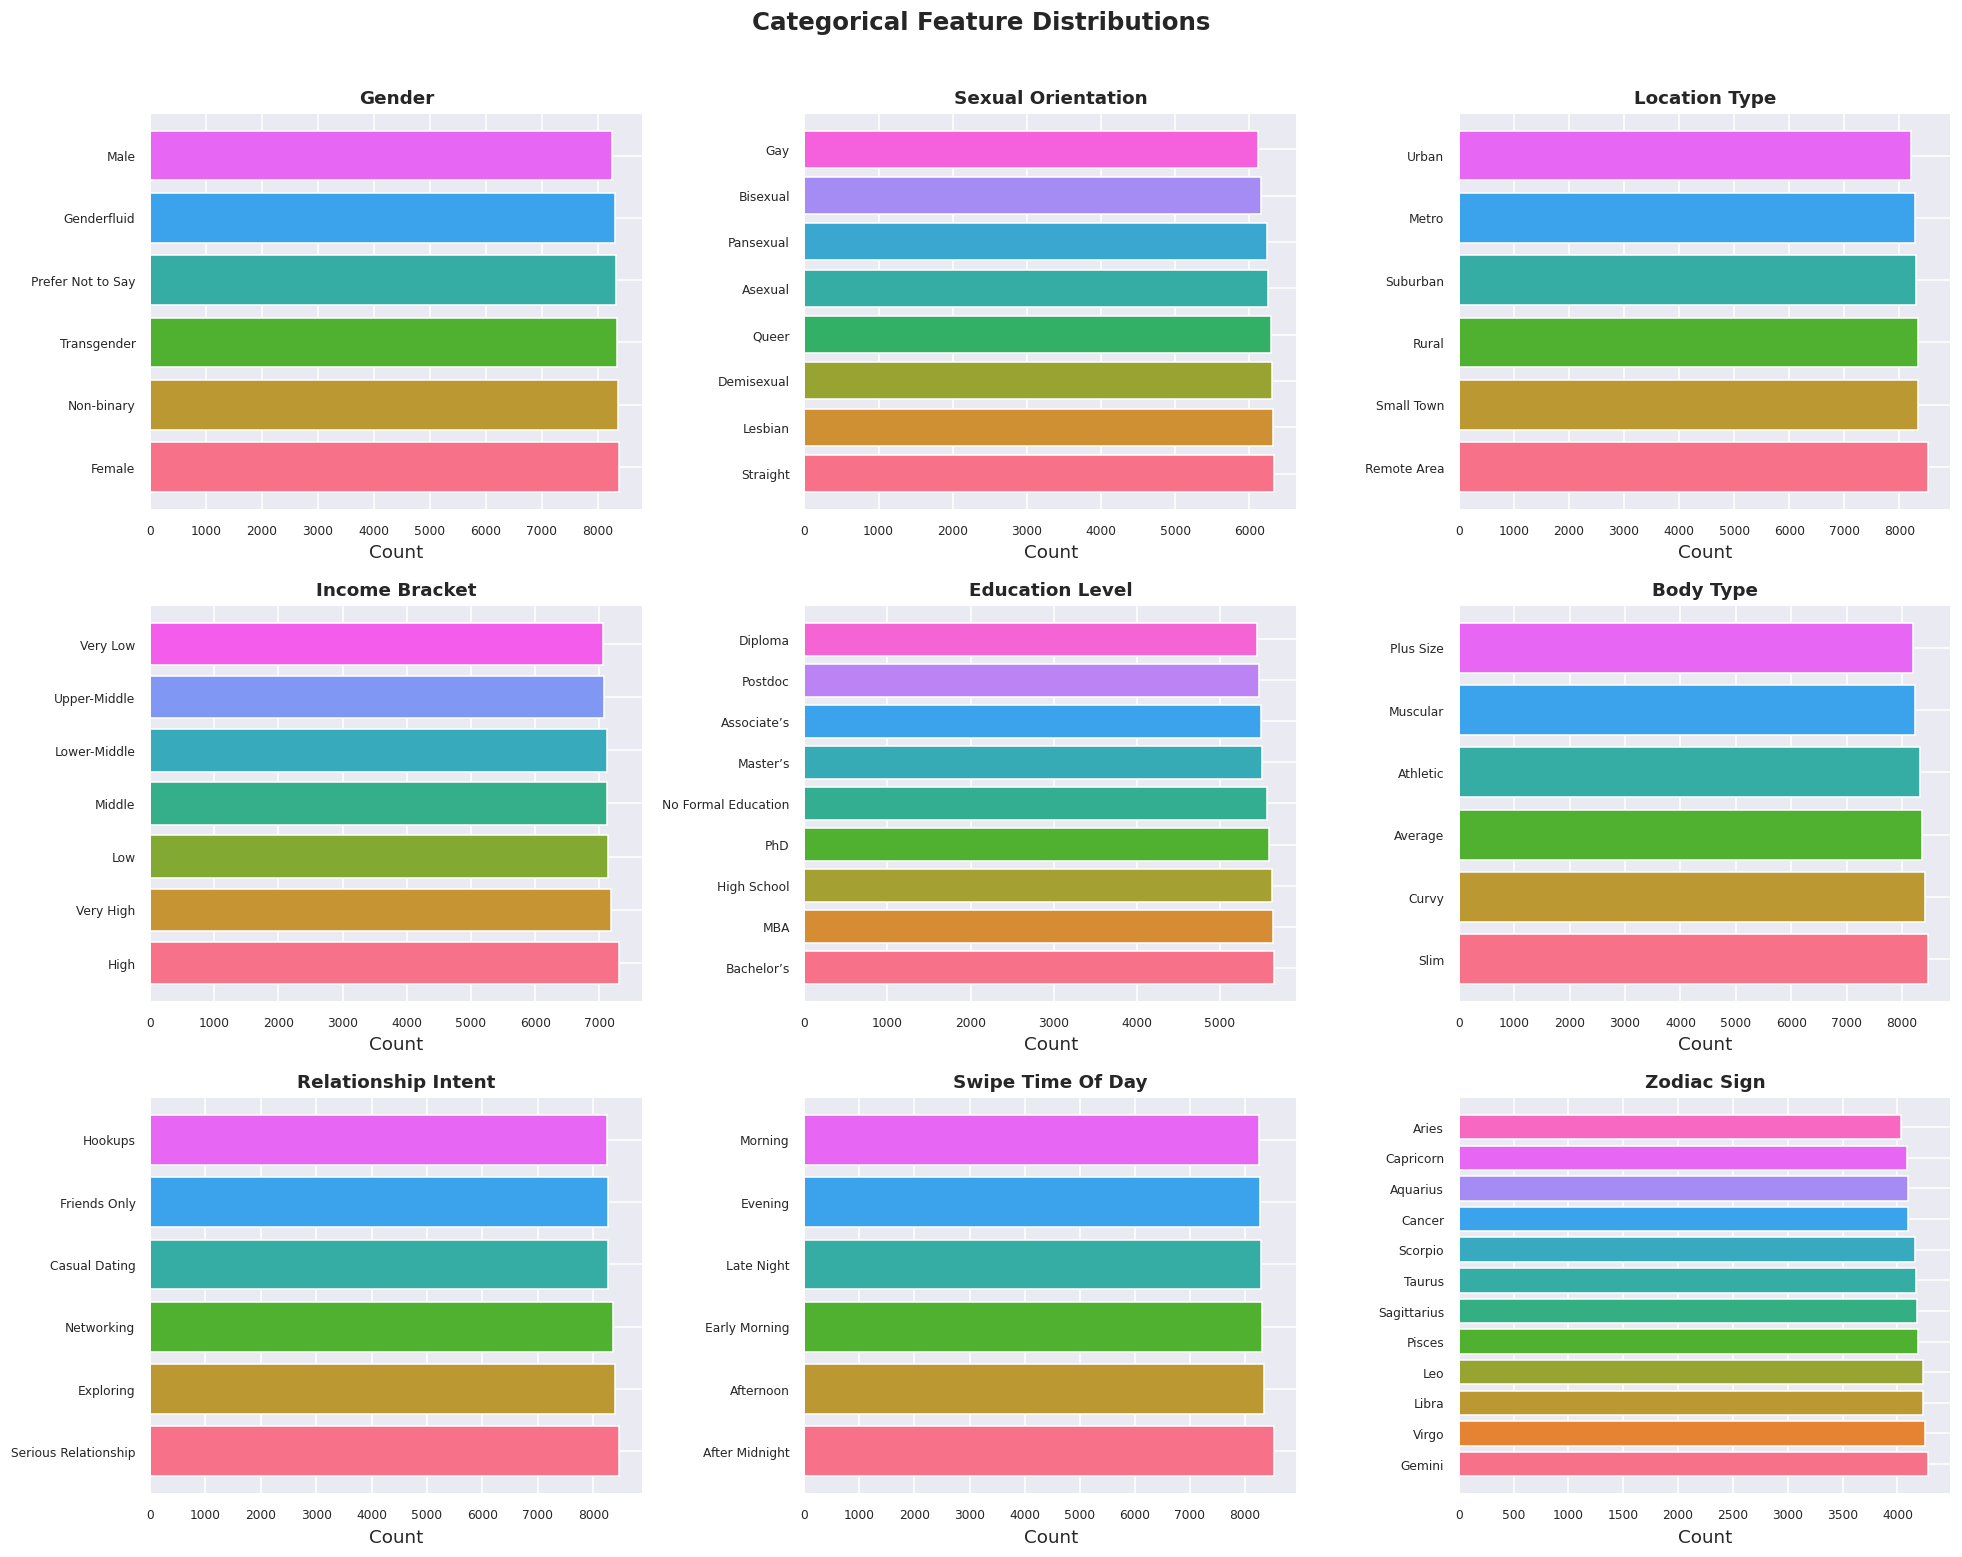

In [ ]:
cat_cols_eda = ['gender', 'sexual_orientation', 'location_type',
                'income_bracket', 'education_level', 'body_type',
                'relationship_intent', 'swipe_time_of_day', 'zodiac_sign']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    vc = df_raw[col].value_counts()
    axes[i].barh(vc.index, vc.values, color=sns.color_palette('husl', len(vc)))
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Numerical Feature Distributions

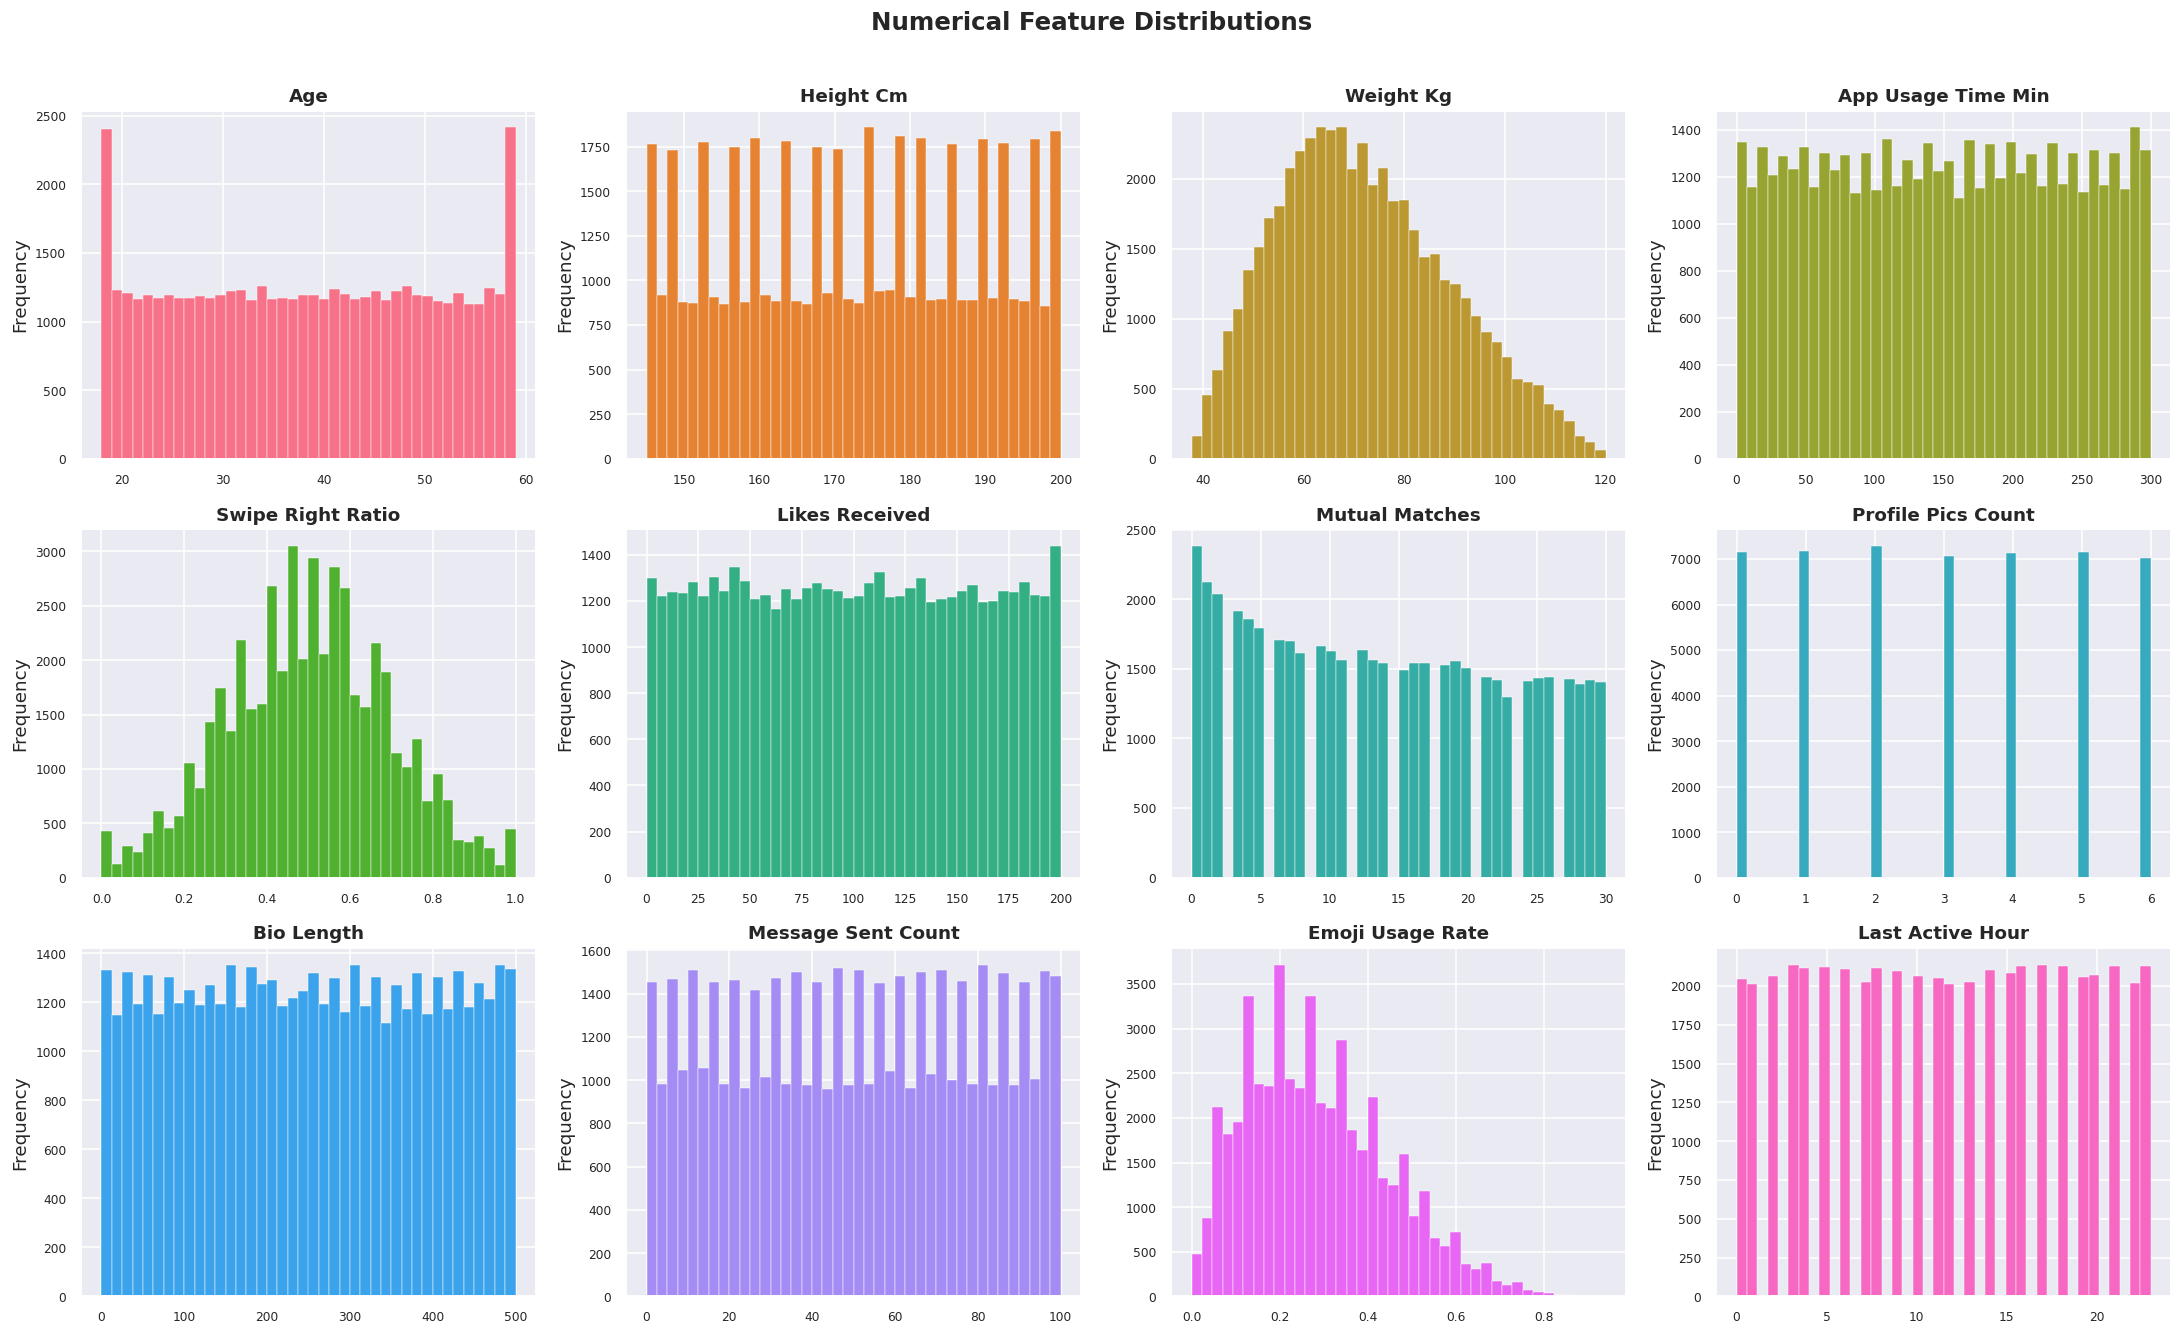

In [ ]:
num_cols_eda = ['age', 'height_cm', 'weight_kg', 'app_usage_time_min',
                'swipe_right_ratio', 'likes_received', 'mutual_matches',
                'profile_pics_count', 'bio_length', 'message_sent_count',
                'emoji_usage_rate', 'last_active_hour']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    axes[i].hist(df_raw[col], bins=40,
                 color=sns.color_palette('husl', 12)[i], edgecolor='white', linewidth=0.3)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.6 Numerical Features — Outlier Detection (Boxplots)

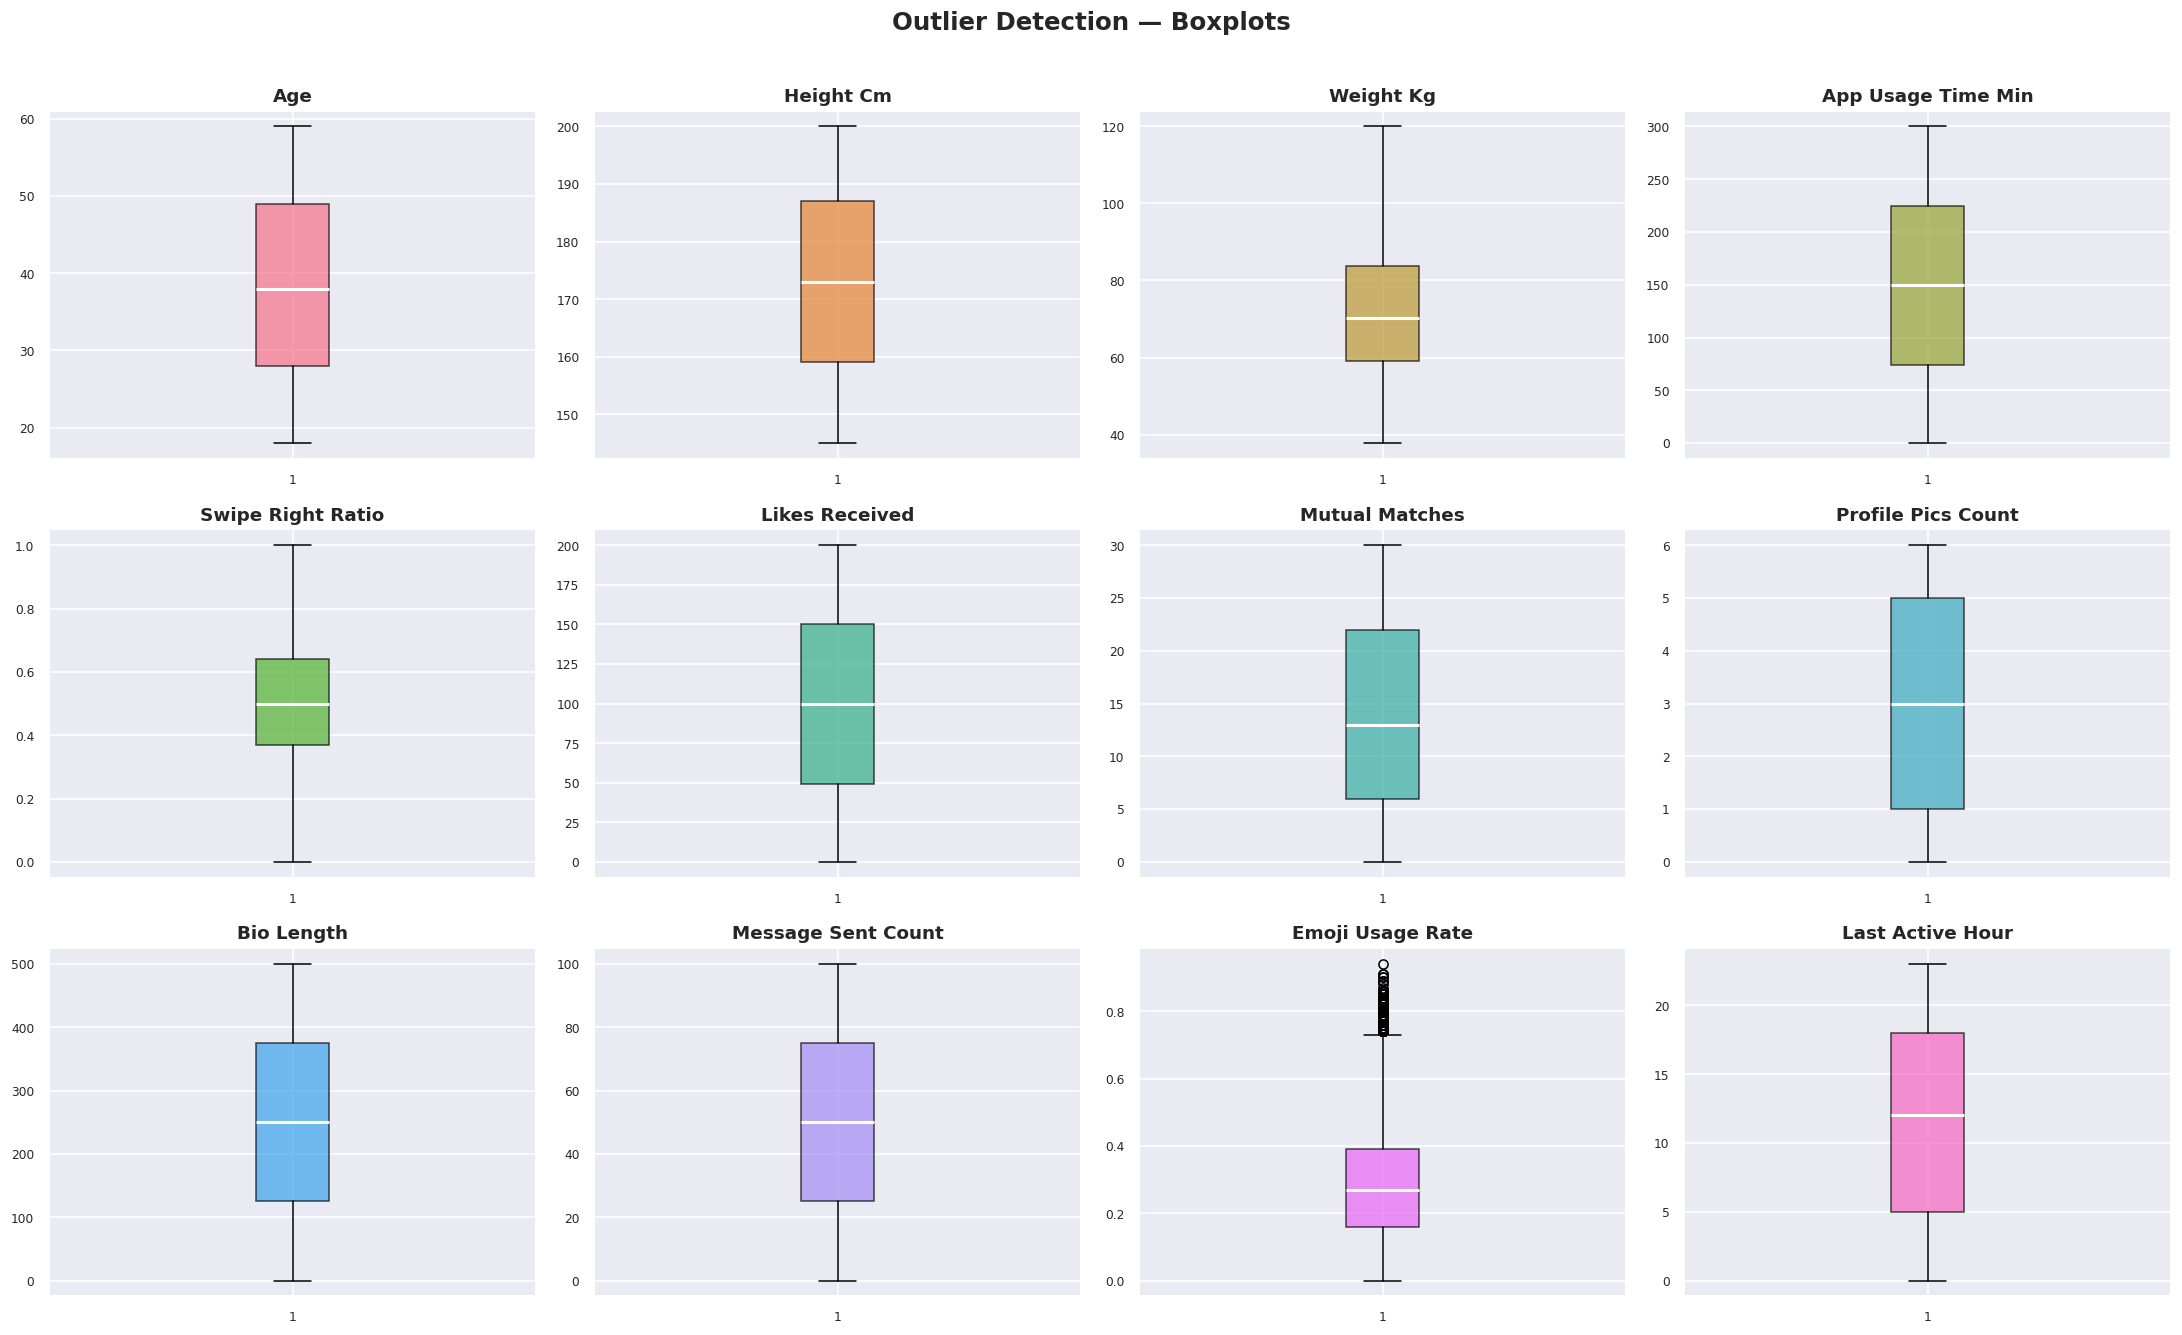

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=sns.color_palette('husl', 12)[i], alpha=0.7),
                    medianprops=dict(color='white', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Outlier Detection — Boxplots', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.7 Feature vs Target — Numerical Features by Outcome

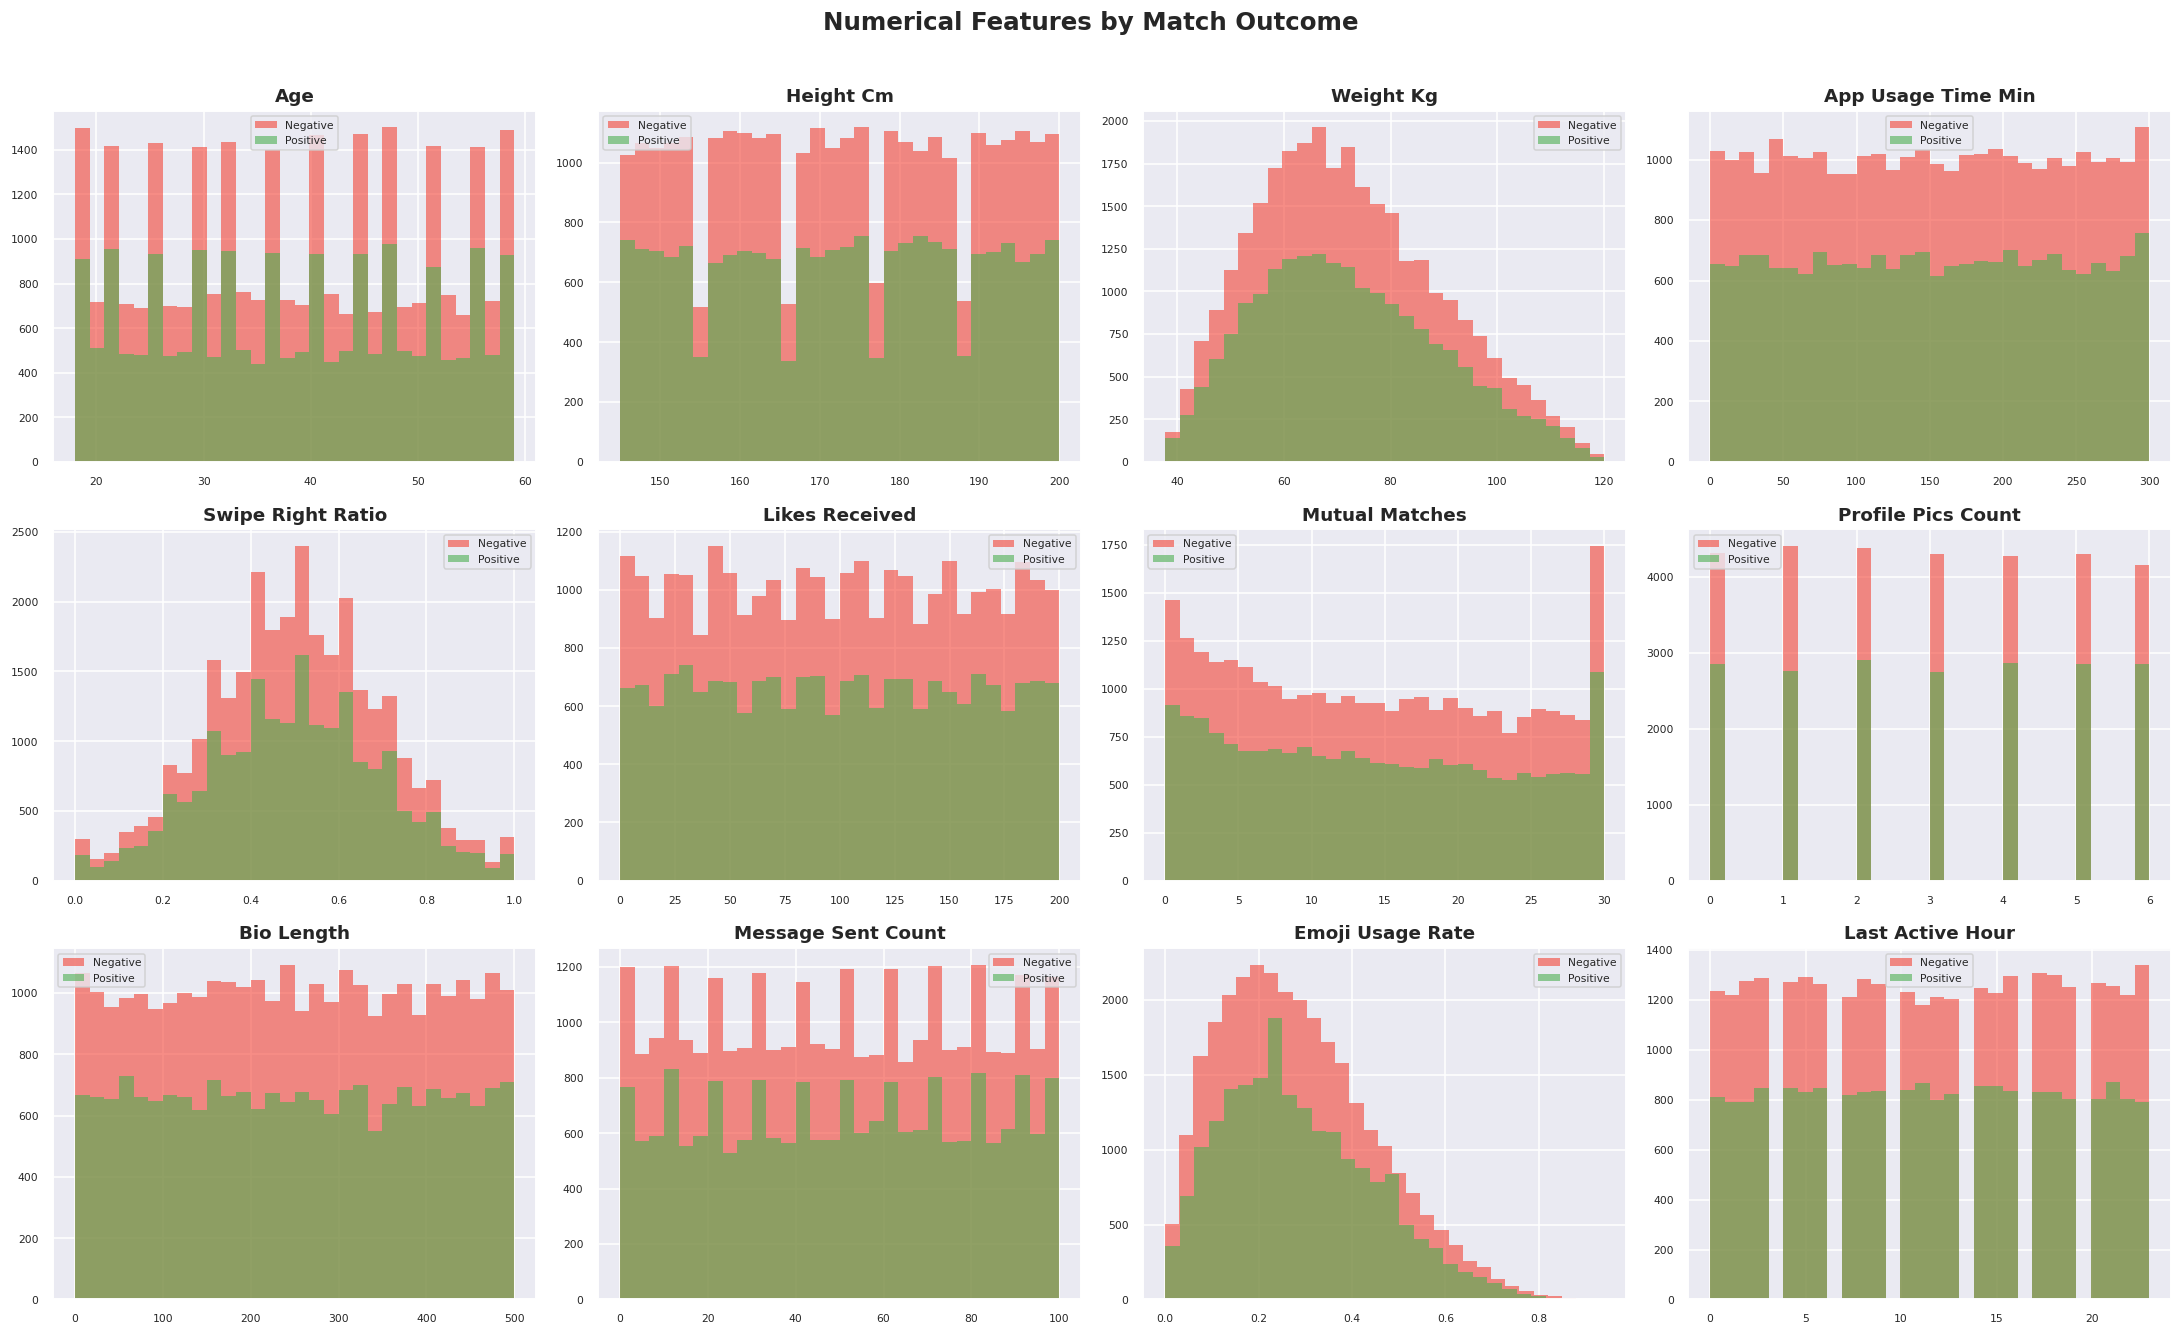

In [ ]:
# Create temporary EDA dataframe with binary outcome label
positive_outcomes_eda = {'Mutual Match', 'Instant Match', 'Date Happened', 'Relationship Formed'}
df_eda = df_raw.copy()
df_eda['outcome_label'] = df_eda['match_outcome'].apply(
    lambda x: 'Positive' if x in positive_outcomes_eda else 'Negative'
)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    pos_vals = df_eda[df_eda['outcome_label'] == 'Positive'][col]
    neg_vals = df_eda[df_eda['outcome_label'] == 'Negative'][col]
    axes[i].hist(neg_vals, bins=30, alpha=0.6, label='Negative', color='#F44336', edgecolor='none')
    axes[i].hist(pos_vals, bins=30, alpha=0.6, label='Positive', color='#4CAF50', edgecolor='none')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Numerical Features by Match Outcome', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.8 Feature vs Target — Categorical Features by Outcome

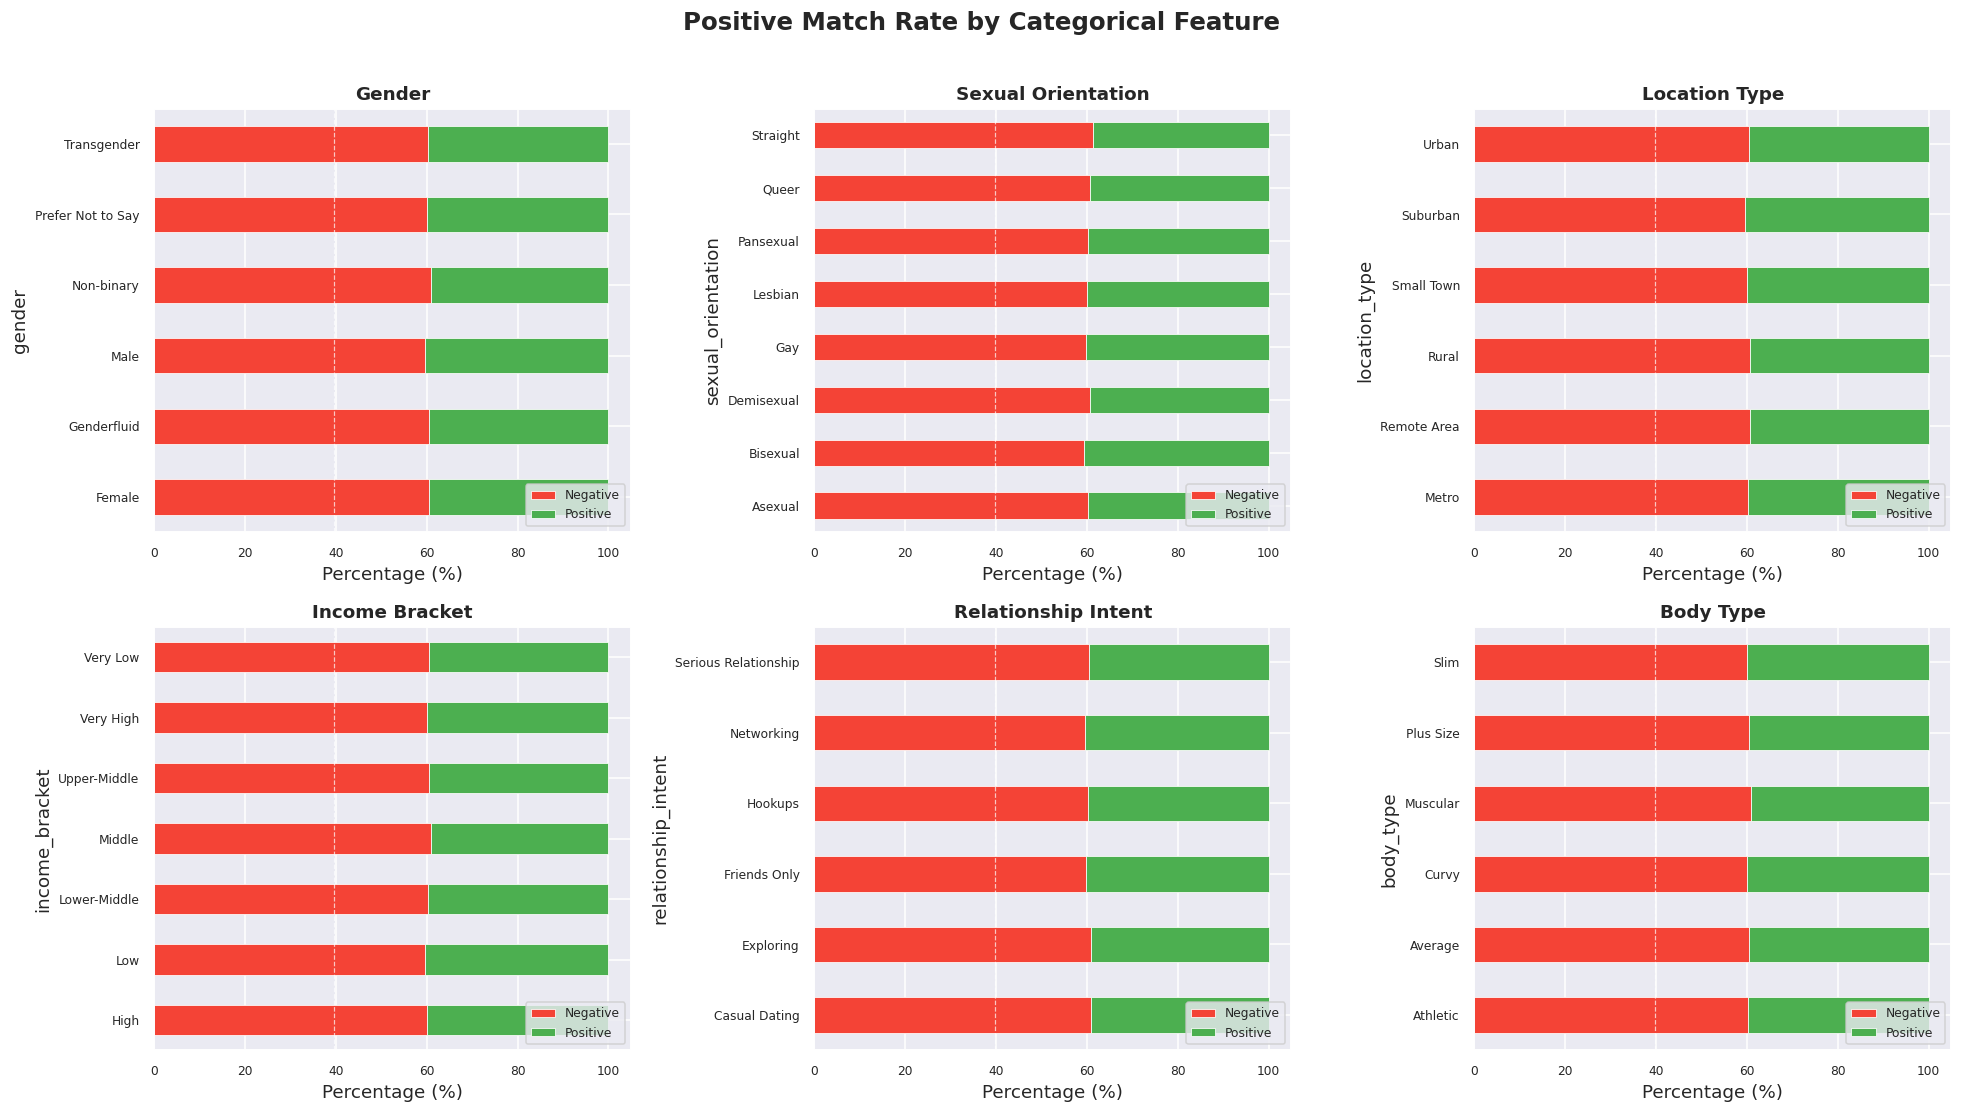

In [ ]:
# Stacked percentage bar charts — shows positive rate per category
cat_subset = ['gender', 'sexual_orientation', 'location_type',
              'income_bracket', 'relationship_intent', 'body_type']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_subset):
    ct = pd.crosstab(df_eda[col], df_eda['outcome_label'], normalize='index') * 100
    # Ensure both columns exist
    for c in ['Negative', 'Positive']:
        if c not in ct.columns:
            ct[c] = 0
    ct[['Negative', 'Positive']].plot(
        kind='barh', ax=axes[i], stacked=True,
        color=['#F44336', '#4CAF50'], edgecolor='white', linewidth=0.5
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Percentage (%)')
    axes[i].legend(loc='lower right', fontsize=8)
    axes[i].tick_params(labelsize=8)
    axes[i].axvline(x=39.7, color='white', linestyle='--', linewidth=0.8, alpha=0.7)

plt.suptitle('Positive Match Rate by Categorical Feature', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.9 Correlation Heatmap (Numerical Features)

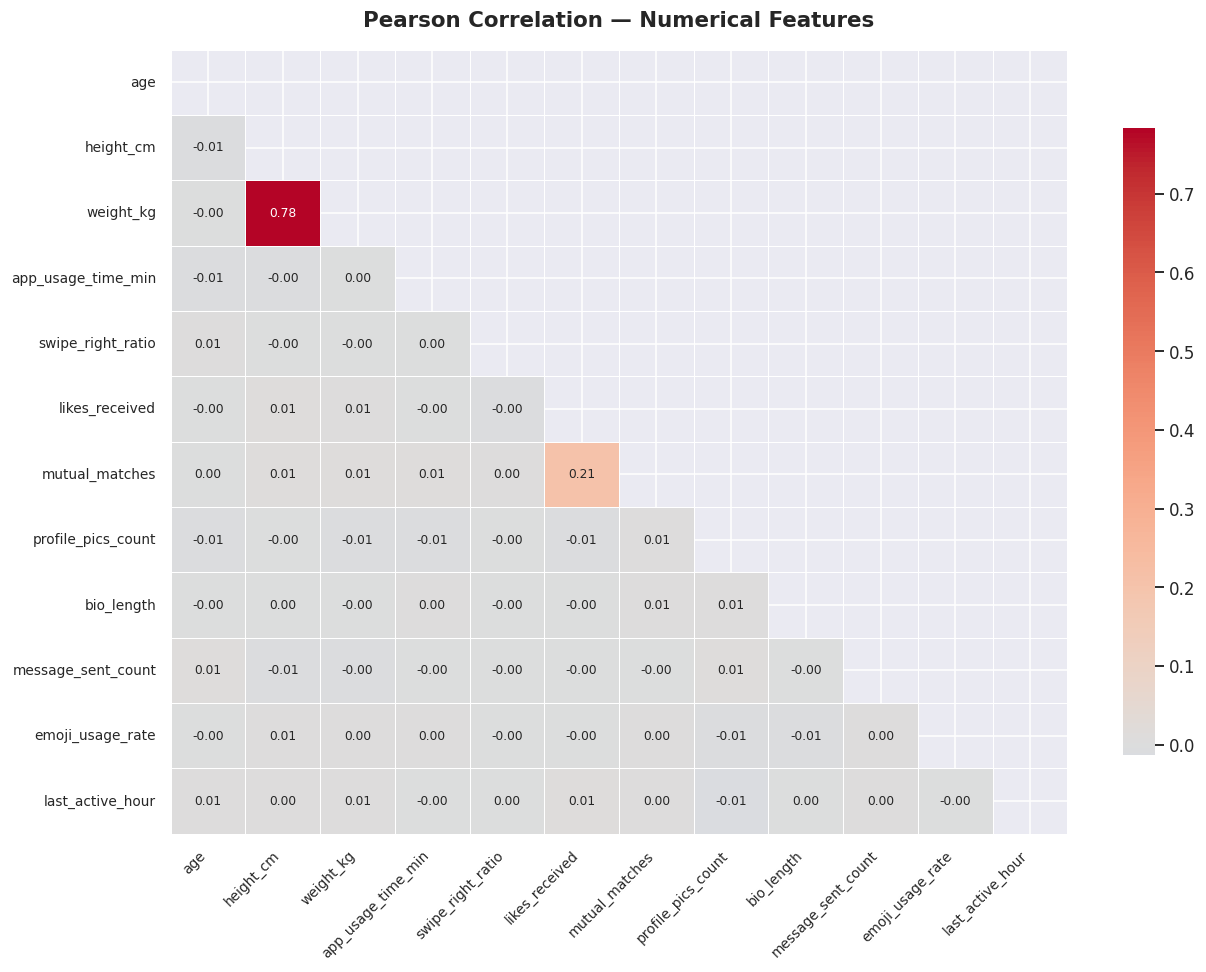

In [ ]:
corr_matrix = df_raw[num_cols_eda].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Pearson Correlation — Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### 3.10 Interest Tags Analysis

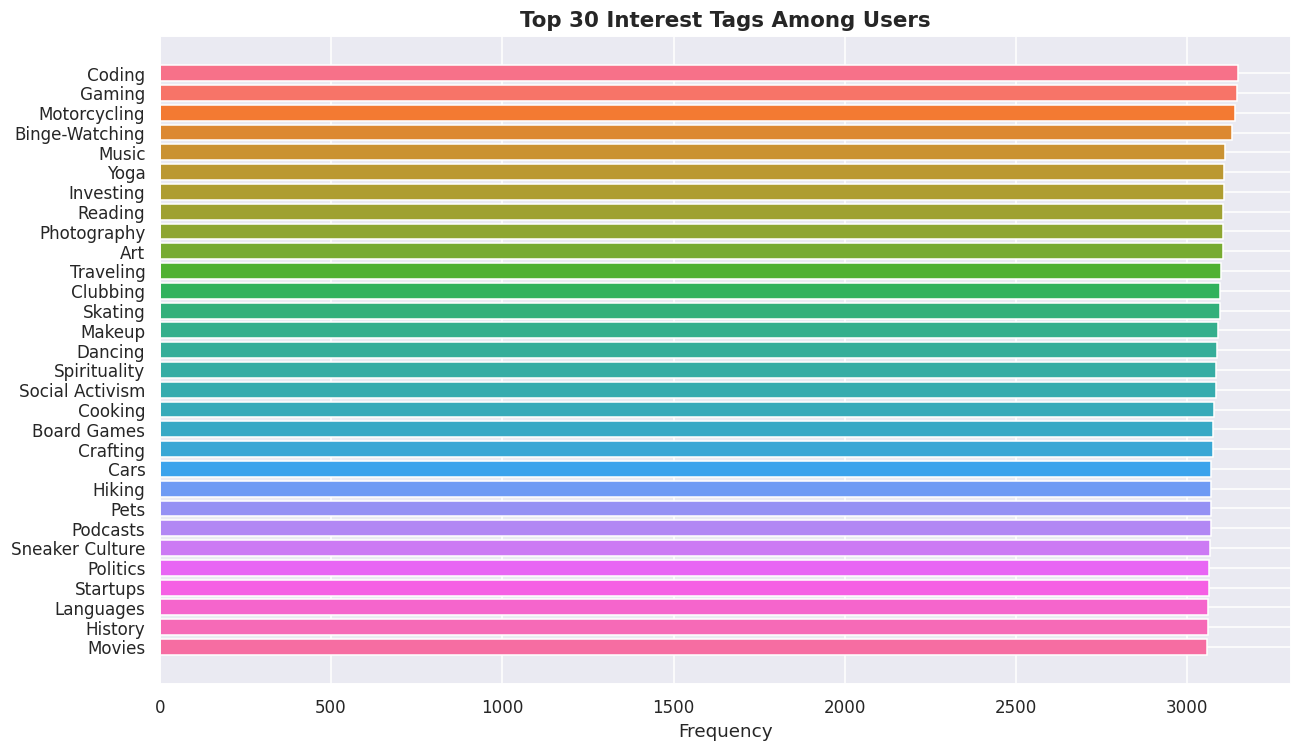

Total unique interest tags: 49


In [ ]:
# Flatten all interest tags and count frequency
all_tags = [tag.strip() for tags in df_raw['interest_tags'].dropna() for tag in tags.split(',')]
tag_counts = Counter(all_tags)
tag_df = pd.DataFrame(tag_counts.most_common(30), columns=['interest', 'count'])

plt.figure(figsize=(12, 7))
colors = sns.color_palette('husl', len(tag_df))
plt.barh(tag_df['interest'], tag_df['count'], color=colors)
plt.title('Top 30 Interest Tags Among Users', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(f'Total unique interest tags: {len(tag_counts)}')

---
## 🧹 Section 4: Data Preprocessing

### 4.1 Create Working Copy & Drop Redundant Columns

In [ ]:
df = df_raw.copy()

# Drop label/string versions of numeric columns (they add no new information)
# app_usage_time_label mirrors app_usage_time_min
# swipe_right_label mirrors swipe_right_ratio
df.drop(columns=['app_usage_time_label', 'swipe_right_label'], inplace=True)

print(f'Shape after dropping redundant columns: {df.shape}')
print('Remaining columns:', df.columns.tolist())

Shape after dropping redundant columns: (50000, 23)
Remaining columns: ['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'interest_tags', 'app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day', 'match_outcome', 'age', 'height_cm', 'weight_kg', 'zodiac_sign', 'body_type', 'relationship_intent']


### 4.2 Create Binary Target Variable

In [ ]:
# Define positive outcome = any form of meaningful connection
positive_outcomes = {'Mutual Match', 'Instant Match', 'Date Happened', 'Relationship Formed'}

df['target'] = df['match_outcome'].apply(lambda x: 1 if x in positive_outcomes else 0)

print('Binary target distribution:')
vc = df['target'].value_counts()
for k, v in vc.items():
    label = 'Positive (Meaningful Connection)' if k == 1 else 'Negative (No Meaningful Connection)'
    print(f'  {k} - {label}: {v:,} ({v/len(df)*100:.1f}%)')

# Drop the original string target — no longer needed for modeling
df.drop(columns=['match_outcome'], inplace=True)

Binary target distribution:
  0 - Negative (No Meaningful Connection): 30,150 (60.3%)
  1 - Positive (Meaningful Connection): 19,850 (39.7%)


### 4.3 Encode Ordinal Feature — income_bracket (7 levels → 3 tiers)

In [ ]:
print('income_bracket unique values:', df['income_bracket'].unique())

# Consolidate 7 granular levels into 3 interpretable tiers
income_map = {
    'Very Low':     'Low',
    'Low':          'Low',
    'Lower-Middle': 'Middle',
    'Middle':       'Middle',
    'Upper-Middle': 'Middle',
    'High':         'High',
    'Very High':    'High'
}
df['income_bracket'] = df['income_bracket'].map(income_map)
print('After mapping:', df['income_bracket'].value_counts().to_dict())

# Ordinal encode: Low=0, Middle=1, High=2
df['income_enc'] = OrdinalEncoder(categories=[['Low', 'Middle', 'High']]).fit_transform(df[['income_bracket']])
df.drop(columns=['income_bracket'], inplace=True)
print('income_enc values:', sorted(df['income_enc'].unique()))

income_bracket unique values: <StringArray>
[        'High', 'Upper-Middle',          'Low',     'Very Low',
       'Middle', 'Lower-Middle',    'Very High']
Length: 7, dtype: str
After mapping: {'Middle': 21320, 'High': 14487, 'Low': 14193}
income_enc values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


### 4.4 Encode Ordinal Feature — education_level (9 levels → 3 tiers)

In [ ]:
print('education_level unique values:', df['education_level'].unique())

# Note: CSV contains curly apostrophes (e.g. Bachelor\u2019s), so we match by keywords
def map_education(val):
    val = str(val)
    if any(k in val for k in ['No Formal', 'High School', 'Diploma']):
        return 'Low'
    elif any(k in val for k in ['Associate', 'Bachelor']):
        return 'Middle'
    elif any(k in val for k in ['Master', 'MBA', 'PhD', 'Postdoc']):
        return 'High'
    return 'Low'  # fallback

df['education_level'] = df['education_level'].apply(map_education)
print('After mapping:', df['education_level'].value_counts().to_dict())

# Ordinal encode: Low=0, Middle=1, High=2
df['education_enc'] = OrdinalEncoder(categories=[['Low', 'Middle', 'High']]).fit_transform(df[['education_level']])
df.drop(columns=['education_level'], inplace=True)
print('education_enc values:', sorted(df['education_enc'].unique()))

education_level unique values: <StringArray>
[         'Bachelor’s', 'No Formal Education',            'Master’s',
             'Postdoc',         'Associate’s',         'High School',
             'Diploma',                 'PhD',                 'MBA']
Length: 9, dtype: str
After mapping: {'High': 22207, 'Low': 16648, 'Middle': 11145}
education_enc values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


### 4.5 One-Hot Encode Nominal Categorical Features

In [ ]:
# These features have no natural order — use one-hot encoding
nominal_cols = [
    'gender',
    'sexual_orientation',
    'location_type',
    'swipe_time_of_day',
    'body_type',
    'relationship_intent',
    'zodiac_sign'
]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=False, dtype=int)

ohe_cols = [c for c in df.columns if any(c.startswith(n + '_') for n in nominal_cols)]
print(f'Shape after one-hot encoding: {df.shape}')
print(f'One-hot encoded columns added: {len(ohe_cols)}')

Shape after one-hot encoding: (50000, 66)
One-hot encoded columns added: 50


### 4.6 Multi-Hot Encode Interest Tags

In [ ]:
# Each user has 3 interests (comma-separated) — create binary columns per unique tag
mlb = MultiLabelBinarizer()
interests_split = df['interest_tags'].str.split(', ')
interest_dummies = pd.DataFrame(
    mlb.fit_transform(interests_split),
    columns=['interest_' + c for c in mlb.classes_],
    index=df.index
)
df = pd.concat([df, interest_dummies], axis=1)
df.drop(columns=['interest_tags'], inplace=True)

print(f'Interest tags encoded: {len(mlb.classes_)} unique tags')
print(f'Shape after interest encoding: {df.shape}')

Interest tags encoded: 49 unique tags
Shape after interest encoding: (50000, 114)


### 4.7 Normalize Numerical Features with StandardScaler

In [ ]:
numeric_cols = [
    'age', 'height_cm', 'weight_kg',
    'app_usage_time_min', 'swipe_right_ratio',
    'likes_received', 'mutual_matches',
    'profile_pics_count', 'bio_length',
    'message_sent_count', 'emoji_usage_rate',
    'last_active_hour'
]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print('Numerical features normalized with StandardScaler')
print('\nPost-normalization stats (mean~0, std~1):')
df[numeric_cols].describe().loc[['mean', 'std']].round(3)

Numerical features normalized with StandardScaler

Post-normalization stats (mean~0, std~1):


,age,height_cm,weight_kg,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour
mean,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 4.8 Final Preprocessed Dataset Overview

In [ ]:
print(f'Final dataset shape: {df.shape}')
print(f'Total features: {df.shape[1] - 1}  |  Target column: target')
print(f'\nMissing values after preprocessing: {df.isnull().sum().sum()}')
print(f'\nData types:')
print(df.dtypes.value_counts())
df.head(3)

Final dataset shape: (50000, 114)
Total features: 113  |  Target column: target

Missing values after preprocessing: 0

Data types:
int64      100
float64     14
Name: count, dtype: int64


,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,age,...,interest_Sneaker Culture,interest_Social Activism,interest_Spirituality,interest_Stand-up Comedy,interest_Startups,interest_Tattoos,interest_Tech,interest_Traveling,interest_Writing,interest_Yoga
0,-1.125564,0.503097,1.266875,1.002657,0.506961,-1.423861,0.854646,0.461100,0.213600,1.444725,...,0,0,0,0,0,0,0,1,0,0
1,1.483942,0.300530,0.128870,-0.754518,0.006150,0.351007,-0.516734,0.836006,-1.664903,0.125498,...,0,0,0,0,0,0,0,0,0,0
2,-1.160051,-0.459093,-0.147010,1.441951,-0.494661,0.406255,-0.585303,0.773521,-1.520402,-0.699019,...,0,0,0,0,0,0,0,0,0,0


---
## 🎯 Section 5: Feature Selection

### 5.1 Prepare Feature Matrix & Target Vector

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')
print(f'\nClass balance:')
print(y.value_counts().rename({0: 'Negative', 1: 'Positive'}))

Feature matrix X: (50000, 113)
Target vector  y: (50000,)

Class balance:
target
Negative    30150
Positive    19850
Name: count, dtype: int64


### 5.2 ANOVA F-Score Feature Selection (SelectKBest)

In [ ]:
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X, y)

f_scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector_f.scores_,
    'p_value': selector_f.pvalues_
}).sort_values('f_score', ascending=False).reset_index(drop=True)

print('Top 25 features by ANOVA F-Score:')
print(f_scores.head(25).to_string(index=False))

Top 25 features by ANOVA F-Score:
                        feature  f_score  p_value
               interest_Cooking 6.560965 0.010427
      swipe_time_of_day_Morning 6.016321 0.014178
                interest_Coding 5.038999 0.024787
swipe_time_of_day_Early Morning 3.567425 0.058929
           zodiac_sign_Aquarius 3.476196 0.062264
                interest_Gaming 3.073365 0.079591
             profile_pics_count 2.990243 0.083774
             message_sent_count 2.928657 0.087026
    sexual_orientation_Straight 2.852104 0.091261
               interest_History 2.838287 0.092049
           interest_Board Games 2.779655 0.095475
    sexual_orientation_Bisexual 2.627164 0.105055
                  interest_Tech 2.618999 0.105597
                 mutual_matches 2.474495 0.115713
 relationship_intent_Networking 2.136903 0.143798
            zodiac_sign_Scorpio 2.090240 0.148249
                   interest_DIY 2.033314 0.153891
                    gender_Male 2.022416 0.154999
      swipe_time

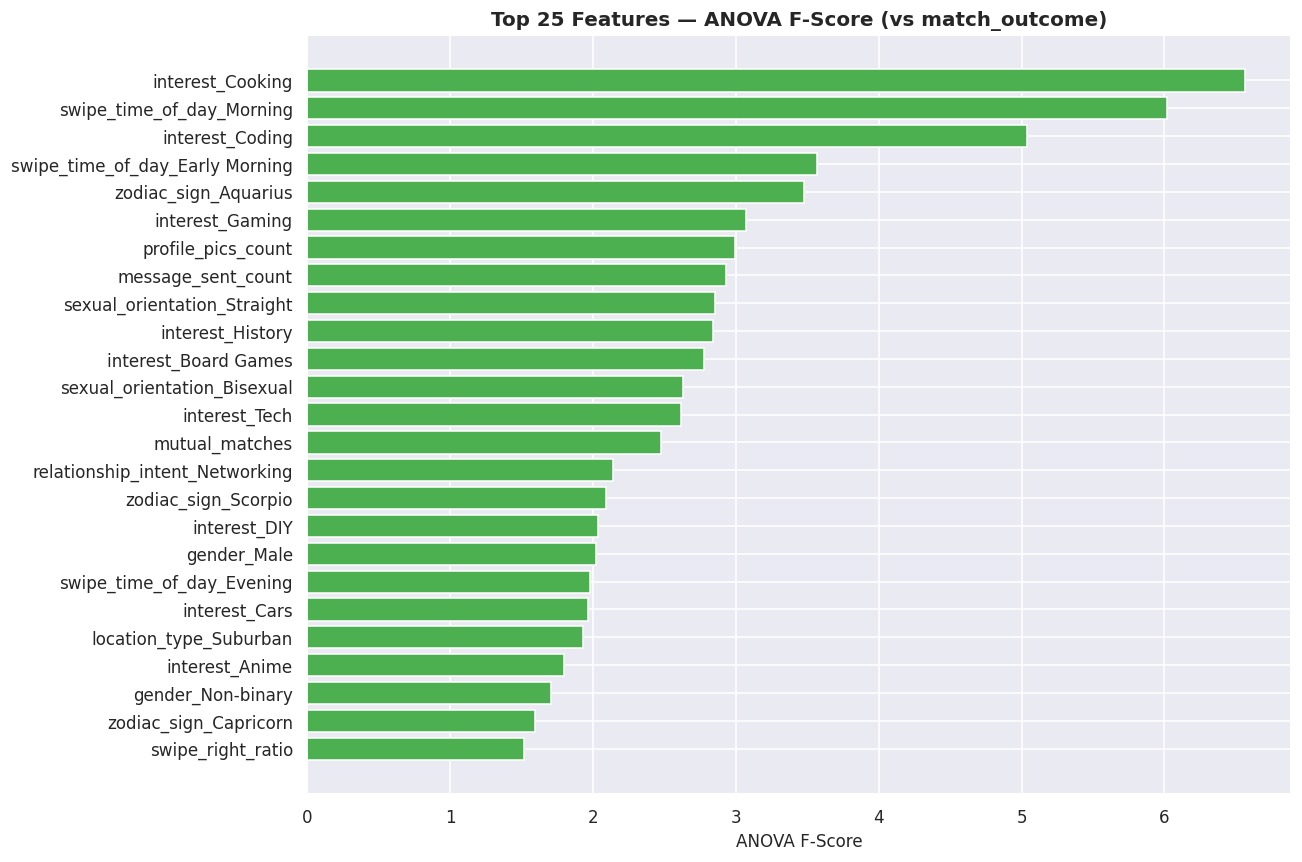

In [ ]:
top25_f = f_scores.head(25)

plt.figure(figsize=(12, 8))
colors_f = ['#4CAF50' if s > f_scores['f_score'].median() else '#90A4AE' for s in top25_f['f_score']]
plt.barh(top25_f['feature'][::-1], top25_f['f_score'][::-1], color=colors_f[::-1])
plt.xlabel('ANOVA F-Score', fontsize=11)
plt.title('Top 25 Features — ANOVA F-Score (vs match_outcome)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Mutual Information Feature Selection

In [ ]:
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)

mi_df = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print('Top 25 features by Mutual Information:')
print(mi_df.head(25).to_string(index=False))

Top 25 features by Mutual Information:
                         feature  mi_score
                   interest_Tech  0.003116
    swipe_time_of_day_Late Night  0.002987
        interest_Sneaker Culture  0.002820
relationship_intent_Friends Only  0.002677
                   education_enc  0.002522
                 interest_Foodie  0.002448
                       height_cm  0.002393
              interest_Traveling  0.002385
                interest_History  0.002290
     sexual_orientation_Bisexual  0.002243
     sexual_orientation_Straight  0.002204
               interest_Podcasts  0.002143
                last_active_hour  0.002077
               gender_Non-binary  0.002073
                  interest_K-pop  0.002068
                interest_Fitness  0.002017
                interest_Dancing  0.001910
              gender_Transgender  0.001829
              interest_Parenting  0.001820
                   gender_Female  0.001797
      sexual_orientation_Lesbian  0.001738
               

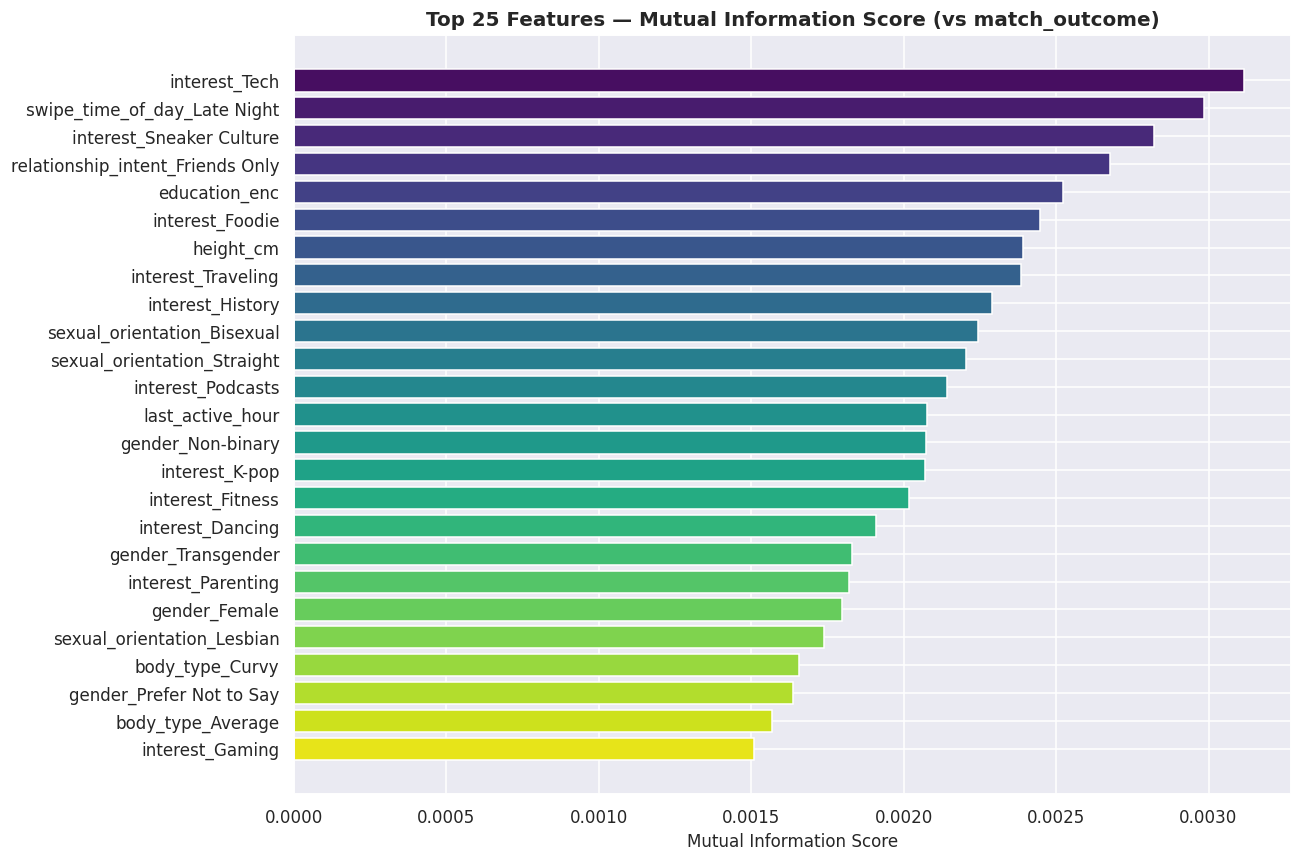

In [ ]:
top25_mi = mi_df.head(25)

plt.figure(figsize=(12, 8))
colors_mi = sns.color_palette('viridis', len(top25_mi))
plt.barh(top25_mi['feature'][::-1], top25_mi['mi_score'][::-1], color=colors_mi[::-1])
plt.xlabel('Mutual Information Score', fontsize=11)
plt.title('Top 25 Features — Mutual Information Score (vs match_outcome)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Select Final Feature Set

In [ ]:
# Keep union of top-40 features from both F-score and Mutual Information rankings
top_f_features  = set(f_scores.head(40)['feature'])
top_mi_features = set(mi_df.head(40)['feature'])
selected_features = sorted(top_f_features.union(top_mi_features))

print(f'Features selected (union of top-40 F & MI): {len(selected_features)}')
print(selected_features)

X_selected = X[selected_features]
print(f'\nX_selected shape: {X_selected.shape}')

Features selected (union of top-40 F & MI): 67
['body_type_Average', 'body_type_Curvy', 'body_type_Muscular', 'body_type_Slim', 'education_enc', 'gender_Female', 'gender_Male', 'gender_Non-binary', 'gender_Prefer Not to Say', 'gender_Transgender', 'height_cm', 'interest_Anime', 'interest_Astrology', 'interest_Binge-Watching', 'interest_Board Games', 'interest_Cars', 'interest_Coding', 'interest_Cooking', 'interest_DIY', 'interest_Dancing', 'interest_Fitness', 'interest_Foodie', 'interest_Gaming', 'interest_Hiking', 'interest_History', 'interest_Investing', 'interest_K-pop', 'interest_Languages', 'interest_Makeup', 'interest_Music', 'interest_Painting', 'interest_Parenting', 'interest_Podcasts', 'interest_Poetry', 'interest_Sneaker Culture', 'interest_Social Activism', 'interest_Tech', 'interest_Traveling', 'interest_Writing', 'last_active_hour', 'location_type_Metro', 'location_type_Remote Area', 'location_type_Suburban', 'message_sent_count', 'mutual_matches', 'profile_pics_count', 'r

---
## 📐 Section 6: Dimensionality Reduction — PCA

### 6.1 Explained Variance Analysis

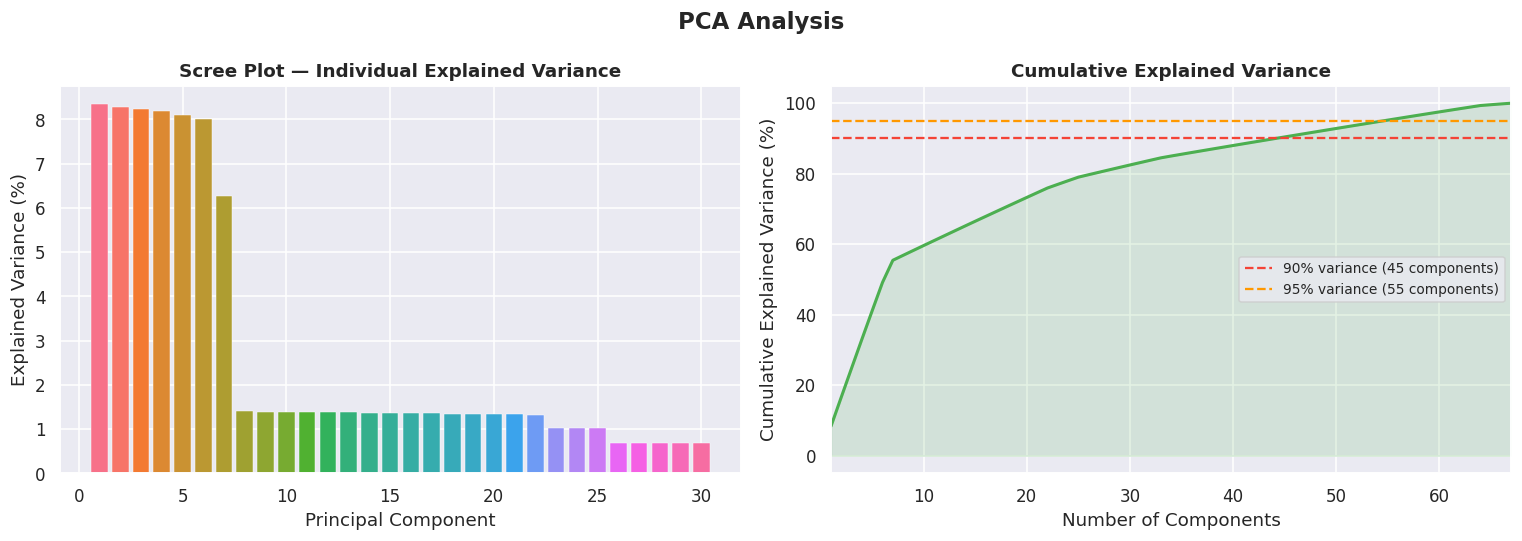

Components needed for 90% variance: 45
Components needed for 95% variance: 55
Total features before PCA:          67


In [ ]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_selected)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_components_90 = int(np.argmax(cumvar >= 90) + 1)
n_components_95 = int(np.argmax(cumvar >= 95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot — individual variance per component
axes[0].bar(
    range(1, min(31, len(pca_full.explained_variance_ratio_) + 1)),
    pca_full.explained_variance_ratio_[:30] * 100,
    color=sns.color_palette('husl', 30), edgecolor='white', linewidth=0.3
)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Individual Explained Variance', fontweight='bold')

# Cumulative explained variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar, color='#4CAF50', linewidth=2)
axes[1].axhline(y=90, color='#F44336', linestyle='--', linewidth=1.5,
                label=f'90% variance ({n_components_90} components)')
axes[1].axhline(y=95, color='#FF9800', linestyle='--', linewidth=1.5,
                label=f'95% variance ({n_components_95} components)')
axes[1].fill_between(range(1, len(cumvar) + 1), cumvar, alpha=0.15, color='#4CAF50')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim([1, min(80, len(cumvar))])

plt.suptitle('PCA Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Components needed for 90% variance: {n_components_90}')
print(f'Components needed for 95% variance: {n_components_95}')
print(f'Total features before PCA:          {X_selected.shape[1]}')

### 6.2 Apply PCA (retain 95% explained variance)

In [ ]:
# We keep BOTH feature sets to compare models with and without PCA
N_COMPONENTS = n_components_95

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_selected)
X_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])

print(f'X_selected shape (original features): {X_selected.shape}')
print(f'X_pca shape     (PCA-reduced):        {X_pca.shape}')
print(f'Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

X_selected shape (original features): (50000, 67)
X_pca shape     (PCA-reduced):        (50000, 55)
Variance retained: 95.20%


### 6.3 PCA Biplot — First Two Principal Components

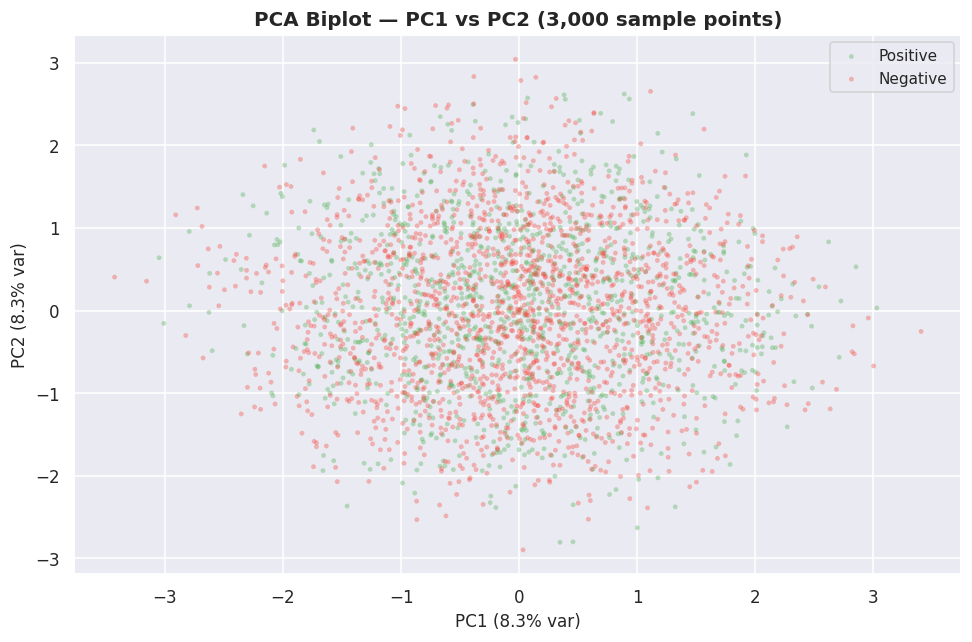

In [ ]:
plt.figure(figsize=(9, 6))
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_pca), size=3000, replace=False)
colors_map = {1: '#4CAF50', 0: '#F44336'}

for label, grp_label in [(1, 'Positive'), (0, 'Negative')]:
    mask = y.values[sample_idx] == label
    plt.scatter(
        X_pca.values[sample_idx][mask, 0],
        X_pca.values[sample_idx][mask, 1],
        c=colors_map[label], label=grp_label, alpha=0.35, s=10, edgecolors='none'
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
plt.title('PCA Biplot — PC1 vs PC2 (3,000 sample points)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## ✂️ Section 7: Train / Test Split

In [ ]:
# --- Split on ORIGINAL selected features (primary — used for most models) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y   # preserves class balance in both splits
)

# --- Split on PCA-reduced features (for PCA comparison models) ---
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('=== Train / Test Split Summary ===')
print(f'  X_train:     {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test:      {X_test.shape}    y_test:  {y_test.shape}')
print(f'\n  X_train_pca: {X_train_pca.shape}')
print(f'  X_test_pca:  {X_test_pca.shape}')
print(f'\nClass balance in y_train:')
print(y_train.value_counts().rename({0: 'Negative', 1: 'Positive'}))
print(f'\nClass balance in y_test:')
print(y_test.value_counts().rename({0: 'Negative', 1: 'Positive'}))

=== Train / Test Split Summary ===
  X_train:     (40000, 67)   y_train: (40000,)
  X_test:      (10000, 67)    y_test:  (10000,)

  X_train_pca: (40000, 55)
  X_test_pca:  (10000, 55)

Class balance in y_train:
target
Negative    24120
Positive    15880
Name: count, dtype: int64

Class balance in y_test:
target
Negative    6030
Positive    3970
Name: count, dtype: int64


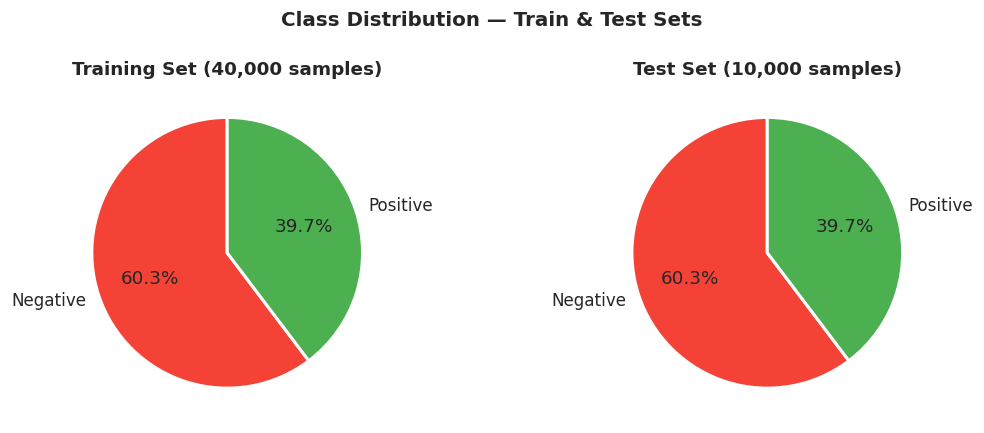

In [ ]:
# Visualise class balance in train and test sets
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, split_y, title in zip(axes, [y_train, y_test], ['Training Set', 'Test Set']):
    vc = split_y.value_counts()
    ax.pie(vc.values, labels=['Negative', 'Positive'],
           autopct='%1.1f%%', colors=['#F44336', '#4CAF50'],
           startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
    ax.set_title(f'{title} ({len(split_y):,} samples)', fontweight='bold')

plt.suptitle('Class Distribution — Train & Test Sets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ Section 8: Pre-Training Checklist

Confirm all preprocessing steps completed before model training:

| Step | Detail | Status |
|---|---|---|
| Dataset loaded | 50,000 rows × 25 features | Done |
| Redundant columns dropped | `app_usage_time_label`, `swipe_right_label` | Done |
| Binary target created | `target`: 0=Negative, 1=Positive (39.7% positive) | Done |
| Ordinal encoding | `income_bracket` (3 tiers), `education_level` (3 tiers) | Done |
| One-hot encoding | gender, orientation, location, body_type, etc. | Done |
| Multi-hot encoding | `interest_tags` (49 unique tags) | Done |
| Numerical normalization | StandardScaler on 12 numeric columns | Done |
| Feature selection | ANOVA F-Score + Mutual Information (top-40 union) | Done |
| PCA | 95% variance retained | Done |
| Train/Test split | 80/20, stratified | Done |
| Missing values | None | Done |

### Objects available for model training:
| Variable | Description |
|---|---|
| `X_train`, `X_test` | Original selected features (40k/10k rows) |
| `y_train`, `y_test` | Binary target labels |
| `X_train_pca`, `X_test_pca` | PCA-reduced features |
| `RANDOM_STATE` | 42 — use in all models for reproducibility |

**Ready for model training!**

---
## 🤖 Section 9: Model Training

We train **6 models** on the original selected features, then compare performance.

| # | Model | Type | Key Characteristics |
|---|---|---|---|
| 1 | Logistic Regression | Linear | Baseline, interpretable, fast |
| 2 | K-Nearest Neighbors | Instance-based | Distance-based, non-parametric |
| 3 | Decision Tree | Tree-based | Fully interpretable |
| 4 | Random Forest | Ensemble (Bagging) | Robust, handles high dimensions |
| 5 | XGBoost | Ensemble (Boosting) | Usually best on tabular data |
| 6 | Support Vector Machine | Kernel-based | Strong with clear margins |

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score, learning_curve
import time

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print('xgboost not installed, using sklearn GradientBoostingClassifier instead')

print('Model libraries loaded')

Model libraries loaded


### 9.1 Define & Train All Models

In [ ]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs', n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, random_state=RANDOM_STATE,
        use_label_encoder=False, eval_metric='logloss',
        tree_method='hist', device=XGB_DEVICE, n_jobs=-1
    ) if HAS_XGBOOST else GradientBoostingClassifier(
        n_estimators=500, random_state=RANDOM_STATE
    ),
    'SVM': BaggingClassifier(
        estimator=SVC(
            kernel='rbf', probability=True, random_state=RANDOM_STATE,
            cache_size=1000, tol=1e-3
        ),
        n_estimators=16,   # Runs 16 models in parallel (1 per thread)
        max_samples=0.20,  # Each thread gets 20% of dataset (~8,000 samples) for higher accuracy
        n_jobs=-1,         # Maxes out all 16 CPU threads
        random_state=RANDOM_STATE
    ),
}

print(f'Models defined: {list(models.keys())}')

Models defined: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']


In [ ]:
# Train all models and collect results (With auto-save and auto-load to avoid repeating hours of training)
import joblib
import os

checkpoint_path = 'baseline_results.joblib'
results = {}

# Robust verification: Ensure the checkpoint exists, is not empty, and contains all models we defined
if os.path.exists(checkpoint_path):
    try:
        temp_results = joblib.load(checkpoint_path)
        # Check that it contains all the keys in our models dictionary
        if temp_results and isinstance(temp_results, dict) and all(m in temp_results for m in models.keys()):
            results = temp_results
            print(f'⚡ Successfully loaded all pre-trained baseline models and metrics from {checkpoint_path}!...')
            # Print loaded results
            for name, r in results.items():
                print(f'  Loaded {name} — Test Acc: {r["test_acc"]:.4f} | F1: {r["f1"]:.4f}')
        else:
            print('⚠️ Checkpoint file is incomplete or empty. Discarding and retraining all models...')
    except Exception as e:
        print(f'⚠️ Error loading checkpoint: {e}. Discarding and retraining all models...')

if not results:
    print('🔄 Training all 6 baseline models (this might take a while)...')
    for name, model in models.items():
        print(f'\n{"="*60}')
        print(f'Training: {name}')
        print(f'{"="*60}')

        start = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start

        # Predictions
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        # Probability predictions (for ROC-AUC)
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)

        # Metrics
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall    = recall_score(y_test, y_pred)
        f1        = f1_score(y_test, y_pred)
        roc_auc   = roc_auc_score(y_test, y_prob)

        results[name] = {
            'model': model,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'train_time': train_time,
            'y_pred': y_pred,
            'y_prob': y_prob
        }

        print(f'  Train Acc: {train_acc:.4f}  |  Test Acc: {test_acc:.4f}')
        print(f'  Precision: {precision:.4f}  |  Recall:   {recall:.4f}')
        print(f'  F1 Score:  {f1:.4f}       |  ROC-AUC:  {roc_auc:.4f}')
        print(f'  Train Time: {train_time:.2f}s')

    # Auto-save results to disk
    joblib.dump(results, checkpoint_path)
    print(f'\n💾 Pre-trained baseline models saved successfully to: {checkpoint_path}')

print(f'\n{"="*60}')
print('All baseline models loaded/trained successfully!')
print(f'{"="*60}')


Training: Logistic Regression
  Train Acc: 0.6030  |  Test Acc: 0.6030
  Precision: 0.0000  |  Recall:   0.0000
  F1 Score:  0.0000       |  ROC-AUC:  0.5014
  Train Time: 0.23s

Training: KNN
  Train Acc: 0.7025  |  Test Acc: 0.5366
  Precision: 0.3951  |  Recall:   0.3149
  F1 Score:  0.3504       |  ROC-AUC:  0.5021
  Train Time: 0.02s

Training: Decision Tree
  Train Acc: 1.0000  |  Test Acc: 0.5112
  Precision: 0.3900  |  Recall:   0.4101
  F1 Score:  0.3998       |  ROC-AUC:  0.4939
  Train Time: 0.71s

Training: Random Forest
  Train Acc: 1.0000  |  Test Acc: 0.5990
  Precision: 0.4145  |  Recall:   0.0244
  F1 Score:  0.0461       |  ROC-AUC:  0.5140
  Train Time: 3.17s

Training: XGBoost
  Train Acc: 0.8528  |  Test Acc: 0.5607
  Precision: 0.4061  |  Recall:   0.2305
  F1 Score:  0.2941       |  ROC-AUC:  0.5092
  Train Time: 0.80s

Training: SVM
  Train Acc: 0.6048  |  Test Acc: 0.6030
  Precision: 0.0000  |  Recall:   0.0000
  F1 Score:  0.0000       |  ROC-AUC:  0.5143
  

### 9.2 Model Comparison Table

In [ ]:
# Build comparison dataframe
if results:
    comparison = pd.DataFrame({
        name: {
            'Train Accuracy': r['train_acc'],
            'Test Accuracy': r['test_acc'],
            'Precision': r['precision'],
            'Recall': r['recall'],
            'F1 Score': r['f1'],
            'ROC-AUC': r['roc_auc'],
            'Train Time (s)': r['train_time'],
            'Overfit Gap': r['train_acc'] - r['test_acc']
        }
        for name, r in results.items()
    }).T

    comparison = comparison.sort_values('Test Accuracy', ascending=False)
    print('Model Comparison (sorted by Test Accuracy):')
    print(comparison.round(4).to_string())
else:
    print('⚠️ No baseline results found to compare. Please ensure Cell 37 trained successfully.')

Model Comparison (sorted by Test Accuracy):
                     Train Accuracy  Test Accuracy  Precision  Recall  F1 Score  ROC-AUC  Train Time (s)  Overfit Gap
Logistic Regression          0.6030         0.6030     0.0000  0.0000    0.0000   0.5014          0.2310       0.0000
SVM                          0.6048         0.6030     0.0000  0.0000    0.0000   0.5143       2433.2371       0.0018
Random Forest                1.0000         0.5990     0.4145  0.0244    0.0461   0.5140          3.1739       0.4010
XGBoost                      0.8528         0.5607     0.4061  0.2305    0.2941   0.5092          0.8037       0.2921
KNN                          0.7024         0.5366     0.3951  0.3149    0.3504   0.5021          0.0189       0.1659
Decision Tree                1.0000         0.5112     0.3900  0.4101    0.3998   0.4939          0.7094       0.4888


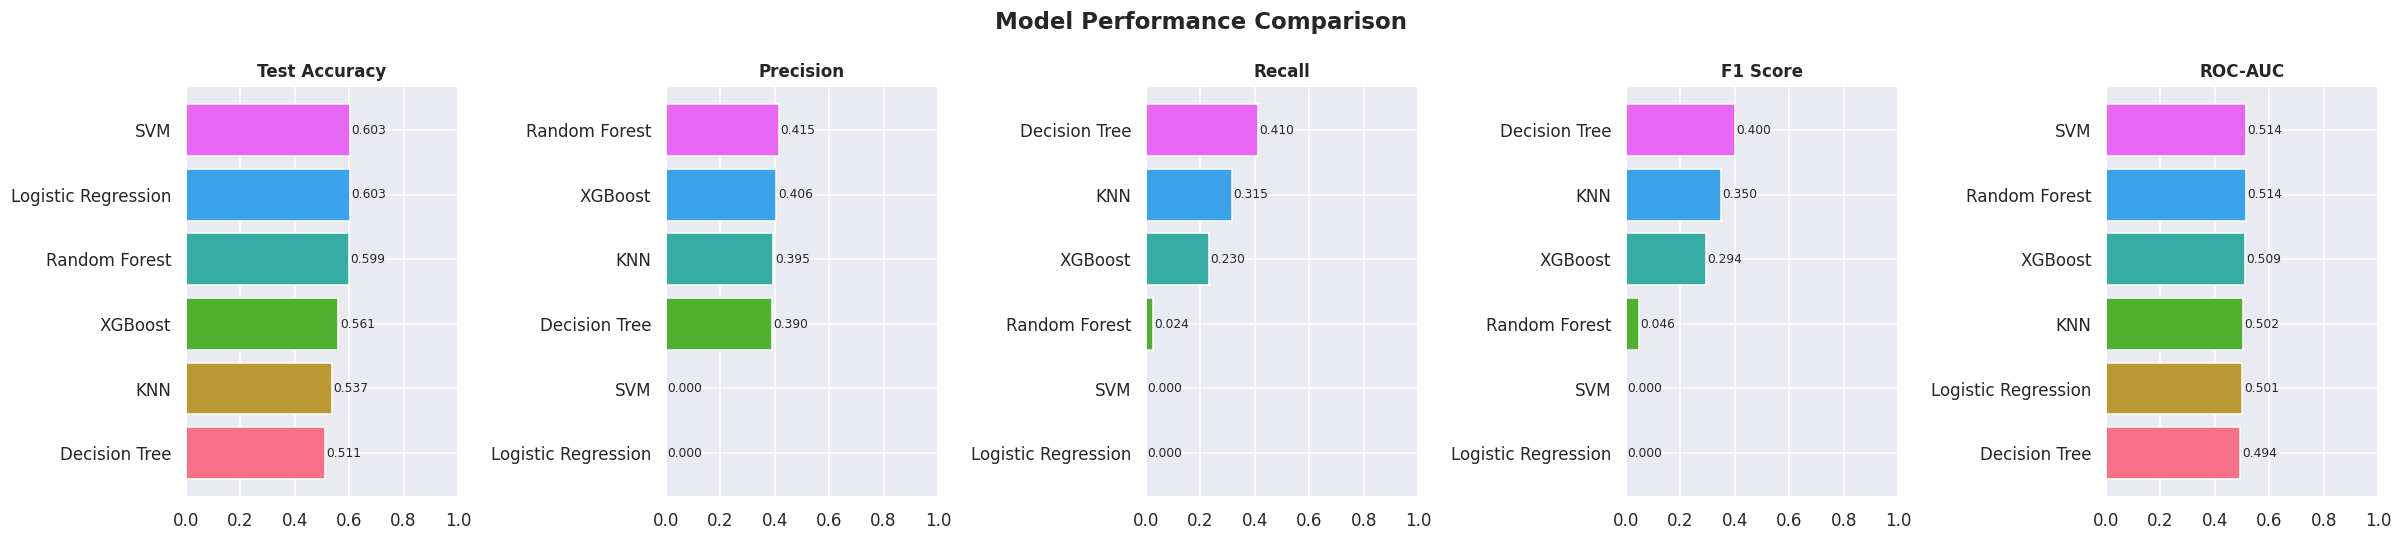

In [ ]:
# Visual comparison — bar chart of key metrics
metrics_to_plot = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 5))

for i, metric in enumerate(metrics_to_plot):
    values = comparison[metric].sort_values(ascending=True)
    colors = sns.color_palette('husl', len(values))
    axes[i].barh(values.index, values.values, color=colors)
    axes[i].set_title(metric, fontweight='bold', fontsize=11)
    axes[i].set_xlim([0, max(values.values.max() * 1.1, 1.0)])
    for j, v in enumerate(values.values):
        axes[i].text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.3 Confusion Matrices

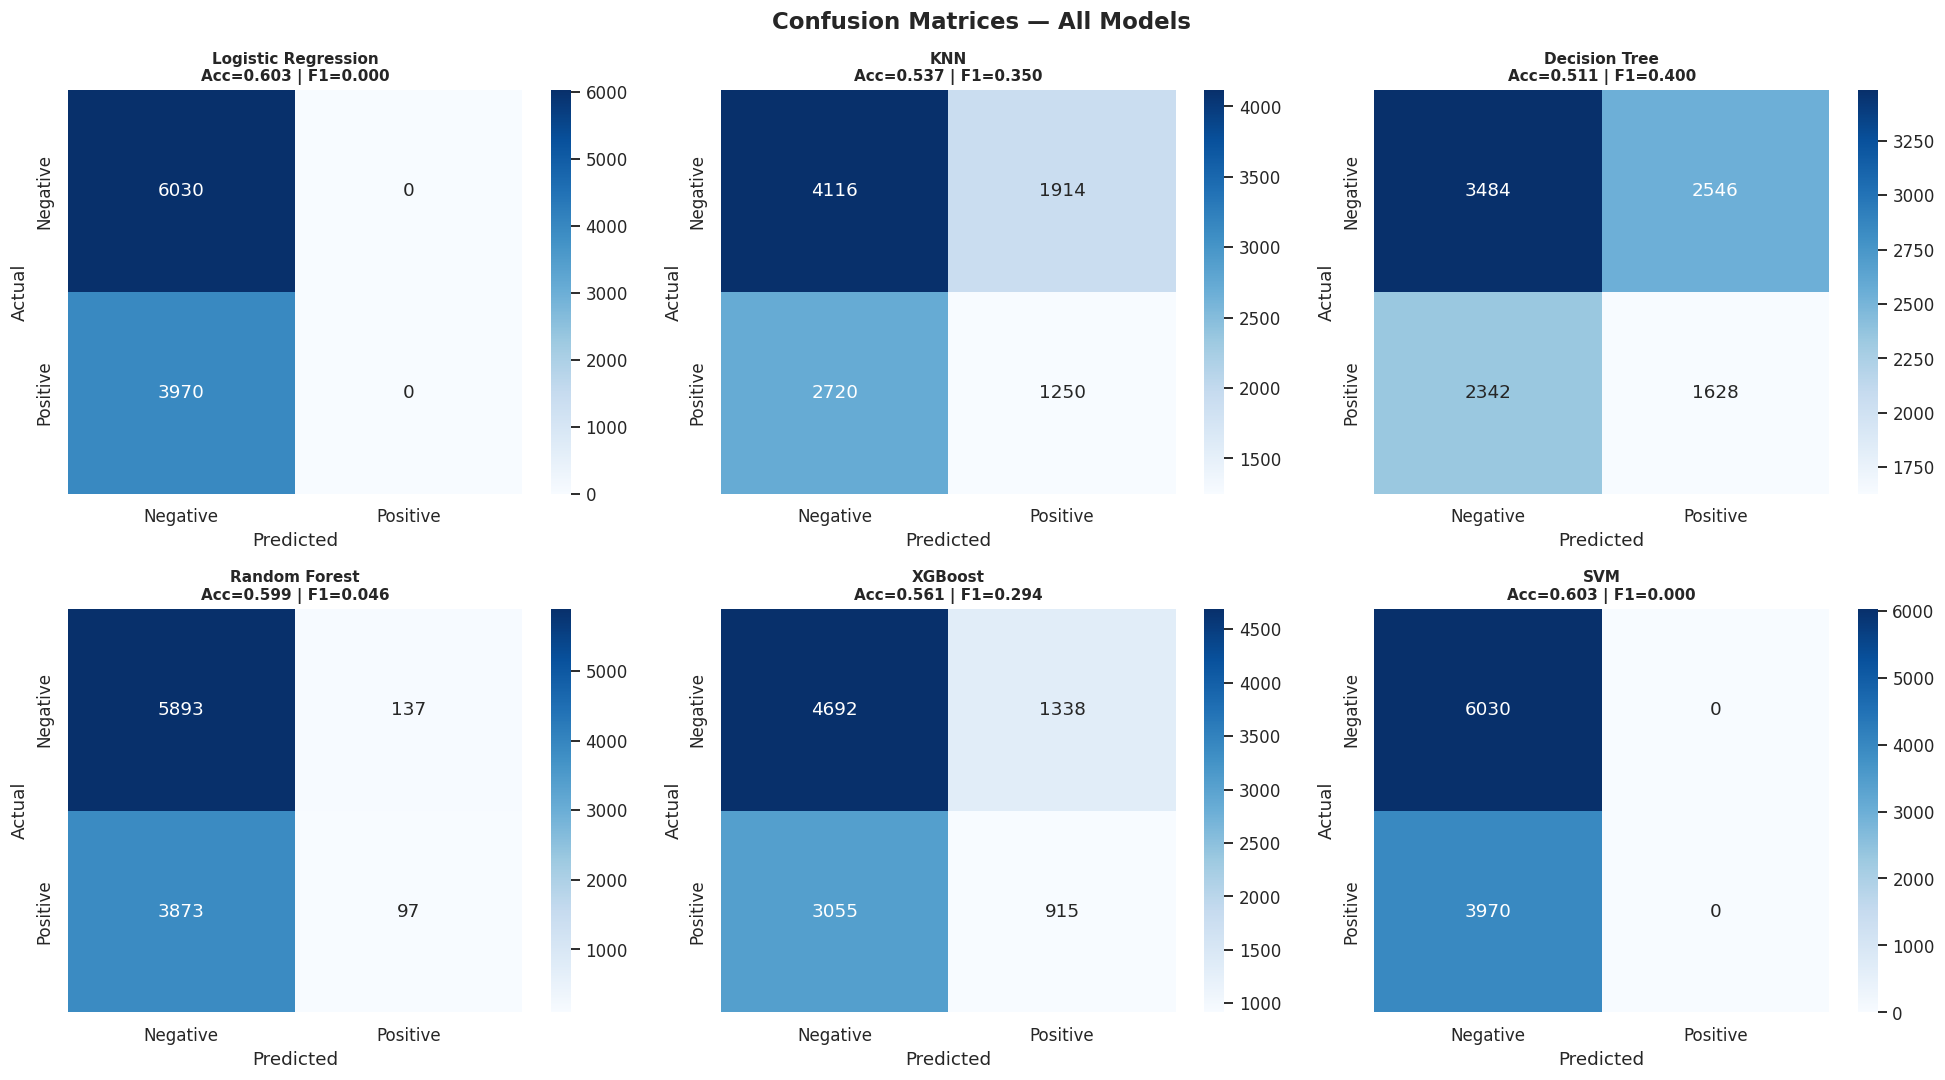

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[i].set_title(f'{name}\nAcc={r["test_acc"]:.3f} | F1={r["f1"]:.3f}',
                      fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.4 ROC Curves

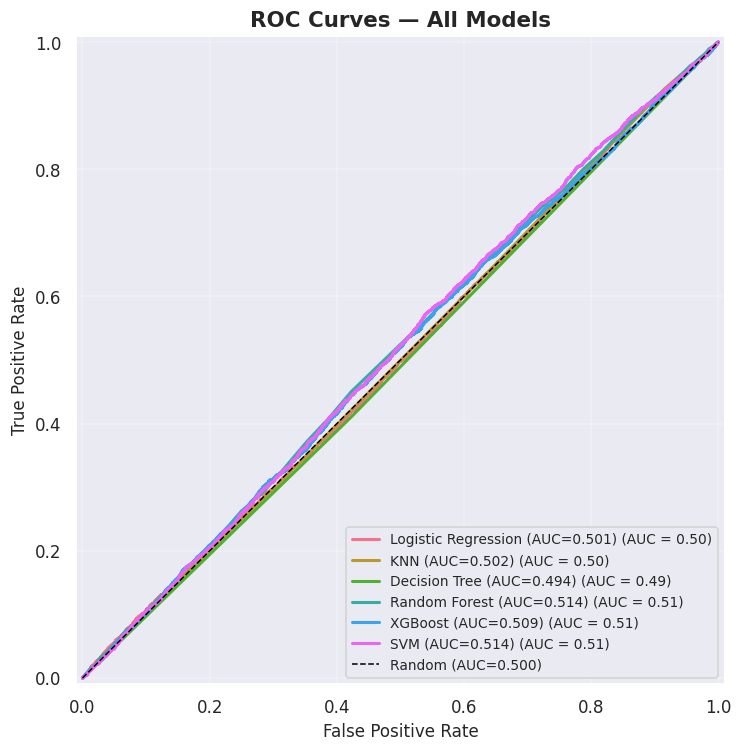

In [ ]:
plt.figure(figsize=(10, 7))
colors = sns.color_palette('husl', len(results))

for i, (name, r) in enumerate(results.items()):
    RocCurveDisplay.from_predictions(
        y_test, r['y_prob'],
        name=f"{name} (AUC={r['roc_auc']:.3f})",
        ax=plt.gca(), color=colors[i], linewidth=2
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.5 Classification Reports

In [ ]:
for name, r in results.items():
    print(f'\n{"="*60}')
    print(f'{name}')
    print(f'{"="*60}')
    print(classification_report(y_test, r['y_pred'],
          target_names=['Negative', 'Positive']))


Logistic Regression
              precision    recall  f1-score   support

    Negative       0.60      1.00      0.75      6030
    Positive       0.00      0.00      0.00      3970

    accuracy                           0.60     10000
   macro avg       0.30      0.50      0.38     10000
weighted avg       0.36      0.60      0.45     10000


KNN
              precision    recall  f1-score   support

    Negative       0.60      0.68      0.64      6030
    Positive       0.40      0.31      0.35      3970

    accuracy                           0.54     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.52      0.54      0.52     10000


Decision Tree
              precision    recall  f1-score   support

    Negative       0.60      0.58      0.59      6030
    Positive       0.39      0.41      0.40      3970

    accuracy                           0.51     10000
   macro avg       0.49      0.49      0.49     10000
weighted avg       0.52      0.51

### 9.6 Cross-Validation Scores (5-Fold)

In [ ]:
import os
import joblib

cv_checkpoint_path = 'cv_results.joblib'
cv_results = {}

print('5-Fold Cross-Validation on Training Set:')
print(f'{"":<25} {"Mean Acc":>10} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 65)

if os.path.exists(cv_checkpoint_path):
    print(f'⚡ Loading pre-computed cross-validation scores from {cv_checkpoint_path} instantly!...')
    cv_results = joblib.load(cv_checkpoint_path)
    for name, cv_scores in cv_results.items():
        print(f'{name:<25} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f} '
              f'{cv_scores.min():>8.4f} {cv_scores.max():>8.4f}')
else:
    print('🔄 Computing cross-validation scores for all models (using 16 threads)...')
    for name, model_info in results.items():
        model = model_info['model']
        
        # Tweak: Temporarily set inner model n_jobs=1 during cross_val_score 
        # to avoid thread oversubscription deadlock with the outer parallel cross_val_score(n_jobs=-1)
        original_n_jobs = getattr(model, 'n_jobs', None)
        if original_n_jobs is not None:
            model.n_jobs = 1
            
        cv_scores = cross_val_score(model, X_train, y_train, cv=5,
                                    scoring='accuracy', n_jobs=-1)
        
        # Restore original n_jobs
        if original_n_jobs is not None:
            model.n_jobs = original_n_jobs
            
        cv_results[name] = cv_scores
        print(f'{name:<25} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f} '
              f'{cv_scores.min():>8.4f} {cv_scores.max():>8.4f}')
              
    # Save scores to disk
    joblib.dump(cv_results, cv_checkpoint_path)
    print(f'\n💾 Cross-validation scores saved successfully to: {cv_checkpoint_path}')

5-Fold Cross-Validation on Training Set:
                            Mean Acc      Std      Min      Max
-----------------------------------------------------------------
Logistic Regression           0.6030   0.0000   0.6029   0.6030
KNN                           0.5365   0.0030   0.5324   0.5413
Decision Tree                 0.5178   0.0031   0.5125   0.5220
Random Forest                 0.5979   0.0011   0.5960   0.5990
XGBoost                       0.5549   0.0035   0.5493   0.5590
SVM                           0.6030   0.0001   0.6029   0.6031


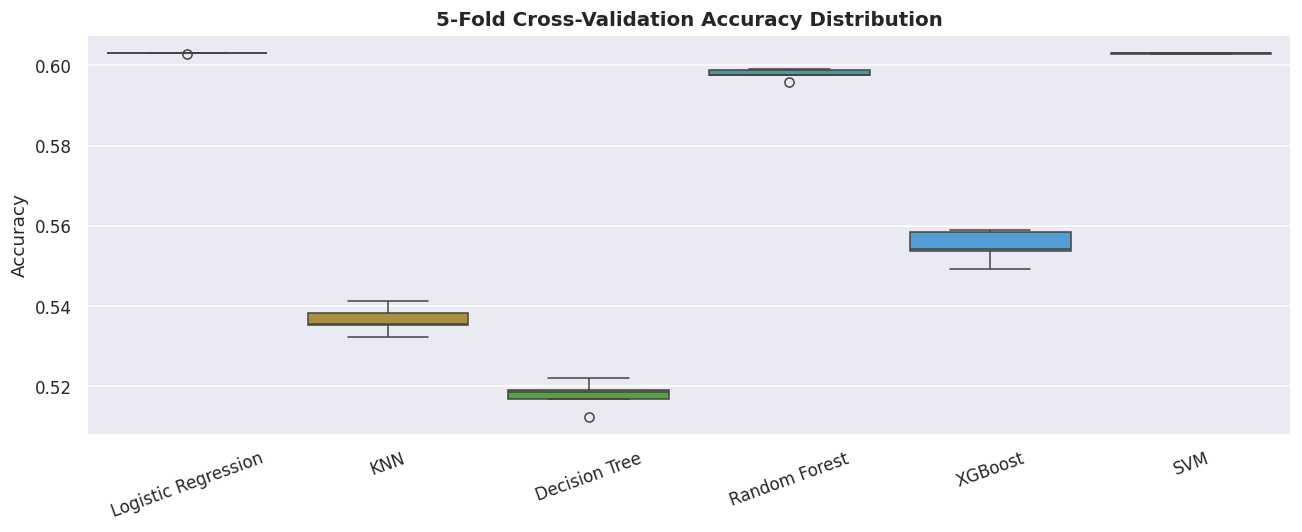

In [ ]:
# Boxplot of cross-validation scores
fig, ax = plt.subplots(figsize=(12, 5))
cv_df = pd.DataFrame(cv_results)
cv_df_melted = cv_df.melt(var_name='Model', value_name='Accuracy')

sns.boxplot(data=cv_df_melted, x='Model', y='Accuracy', palette='husl', ax=ax)
ax.set_title('5-Fold Cross-Validation Accuracy Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### 9.7 Learning Curves — Top 3 Models

In [1]:
# Identify top 3 models by test accuracy
top3 = comparison.head(3).index.tolist()
print(f'Top 3 models for learning curves: {top3}')

import joblib
import os

lc_checkpoint_path = 'learning_curve_data.joblib'
lc_data = {}

if os.path.exists(lc_checkpoint_path):
    print(f'⚡ Loading computed learning curve data from {lc_checkpoint_path} instantly!...')
    lc_data = joblib.load(lc_checkpoint_path)
else:
    print('🔄 Learning curve data not found. Running cross-validation across sizes (this might take a while)...')
    for name in top3:
        model = results[name]['model']
        print(f'  Computing learning curve for: {name}')
        train_sizes, train_scores, val_scores = learning_curve(
            model, X_train, y_train,
            train_sizes=np.linspace(0.1, 1.0, 8),
            cv=5, scoring='accuracy', n_jobs=-1
        )
        lc_data[name] = {
            'train_sizes': train_sizes,
            'train_scores': train_scores,
            'val_scores': val_scores
        }
    # Save computed learning curves to disk
    joblib.dump(lc_data, lc_checkpoint_path)
    print(f'💾 Computed learning curve data saved successfully to: {lc_checkpoint_path}')

# Plot learning curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(top3):
    data = lc_data[name]
    train_sizes = data['train_sizes']
    train_scores = data['train_scores']
    val_scores = data['val_scores']

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    axes[i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#4CAF50')
    axes[i].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#F44336')
    axes[i].plot(train_sizes, train_mean, 'o-', color='#4CAF50', label='Training', linewidth=2)
    axes[i].plot(train_sizes, val_mean, 'o-', color='#F44336', label='Validation', linewidth=2)
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Training Set Size')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Learning Curves — Top 3 Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'comparison' is not defined

---
## 🔧 Section 10: Hyperparameter Tuning

We apply `RandomizedSearchCV` to the **top 3 performing models** from the baseline comparison.
This explores a random subset of the parameter space with 5-fold cross-validation.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print('Hyperparameter tuning libraries loaded')

### 10.1 Define Search Spaces

In [ ]:
# Define parameter grids for top models
param_grids = {
    'Random Forest': {
        'n_estimators': [200, 300, 500, 800, 1000],
        'max_depth': [None, 10, 20, 30, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': [200, 300, 500, 800, 1000],
        'max_depth': [3, 5, 7, 10, 12],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]
    },
    'SVM': {
        'estimator__C': [0.1, 1, 10, 100],
        'estimator__gamma': ['scale', 'auto', 0.01, 0.001],
        'estimator__kernel': ['rbf', 'poly']
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 11, 15, 21],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'Decision Tree': {
        'max_depth': [None, 5, 10, 20, 30],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 4, 8],
        'criterion': ['gini', 'entropy']
    }
}

print('Parameter search spaces defined for:', list(param_grids.keys()))


### 10.2 Run Hyperparameter Search (Top 3 Models)

In [ ]:
# Tune the top 3 models (With auto-save and auto-load to avoid repeating hours of tuning)
import os
import joblib
checkpoint_tuned_path = 'tuned_results.joblib'
tuned_results = {}

if os.path.exists(checkpoint_tuned_path):
    print(f'⚡ Loading pre-trained tuned models and metrics from {checkpoint_tuned_path} instantly!...')
    tuned_results = joblib.load(checkpoint_tuned_path)
    for name, r in tuned_results.items():
        print(f'  Loaded Tuned {name} — Test Acc: {r["test_acc"]:.4f} | F1: {r["f1"]:.4f}')
else:
    print('🔄 Tuned results not found. Running hyperparameter tuning on top 3 models (this might take a while)...')
    for name in top3:
        print(f'\n{"="*60}')
        print(f'Tuning: {name}')
        print(f'{"="*60}')

        if name not in param_grids:
            print(f'  No parameter grid defined for {name}, skipping.')
            continue

        # Create fresh model instance
        # Note: We do NOT use n_jobs=-1 inside base estimators here because RandomizedSearchCV
        # is already running in parallel with n_jobs=-1. This avoids CPU thread conflicts.
        base_models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            'KNN': KNeighborsClassifier(),
            'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
            'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
            'XGBoost': XGBClassifier(
                random_state=RANDOM_STATE, use_label_encoder=False,
                eval_metric='logloss', tree_method='hist',
                device=XGB_DEVICE
            ) if HAS_XGBOOST else GradientBoostingClassifier(random_state=RANDOM_STATE),
            'SVM': BaggingClassifier(
            estimator=SVC(probability=True, random_state=RANDOM_STATE, cache_size=500, tol=1e-3),
            n_estimators=16, max_samples=0.20, n_jobs=-1, random_state=RANDOM_STATE
        ),
        }

        search = RandomizedSearchCV(
            estimator=base_models[name],
            param_distributions=param_grids[name],
            n_iter=30,
            cv=5,
            scoring='f1',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1
        )

        start = time.time()
        search.fit(X_train, y_train)
        tune_time = time.time() - start

        best_model = search.best_estimator_
        y_pred_tuned = best_model.predict(X_test)

        if hasattr(best_model, 'predict_proba'):
            y_prob_tuned = best_model.predict_proba(X_test)[:, 1]
        else:
            y_prob_tuned = best_model.decision_function(X_test)

        tuned_results[name] = {
            'model': best_model,
            'best_params': search.best_params_,
            'best_cv_score': search.best_score_,
            'test_acc': accuracy_score(y_test, y_pred_tuned),
            'precision': precision_score(y_test, y_pred_tuned),
            'recall': recall_score(y_test, y_pred_tuned),
            'f1': f1_score(y_test, y_pred_tuned),
            'roc_auc': roc_auc_score(y_test, y_prob_tuned),
            'tune_time': tune_time,
            'y_pred': y_pred_tuned,
            'y_prob': y_prob_tuned
        }

        print(f'\n  Best Parameters: {search.best_params_}')
        print(f'  Best CV F1:     {search.best_score_:.4f}')
        print(f'  Test Accuracy:  {tuned_results[name]["test_acc"]:.4f}')
        print(f'  Test F1:        {tuned_results[name]["f1"]:.4f}')
        print(f'  Test ROC-AUC:   {tuned_results[name]["roc_auc"]:.4f}')
        print(f'  Tuning Time:    {tune_time:.1f}s')

    # Auto-save tuned results to disk
    joblib.dump(tuned_results, checkpoint_tuned_path)
    print(f'\n💾 Pre-trained tuned models saved successfully to: {checkpoint_tuned_path}')

print(f'\n{"="*60}')
print('Hyperparameter tuning complete!')
print(f'{"="*60}')


### 10.3 Before vs After Tuning Comparison

In [ ]:
# Compare baseline vs tuned for the top 3
print(f'{"Model":<25} {"Metric":<12} {"Baseline":>10} {"Tuned":>10} {"Change":>10}')
print('-' * 70)

for name in top3:
    if name not in tuned_results:
        continue
    baseline = results[name]
    tuned = tuned_results[name]
    for metric in ['test_acc', 'f1', 'roc_auc']:
        label = {'test_acc': 'Accuracy', 'f1': 'F1 Score', 'roc_auc': 'ROC-AUC'}[metric]
        b_val = baseline[metric]
        t_val = tuned[metric]
        change = t_val - b_val
        arrow = '+' if change >= 0 else ''
        print(f'{name:<25} {label:<12} {b_val:>10.4f} {t_val:>10.4f} {arrow}{change:>9.4f}')
    print()

In [ ]:
# Visual comparison — baseline vs tuned
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(['test_acc', 'f1', 'roc_auc']):
    label = {'test_acc': 'Accuracy', 'f1': 'F1 Score', 'roc_auc': 'ROC-AUC'}[metric]
    model_names = [n for n in top3 if n in tuned_results]
    baseline_vals = [results[n][metric] for n in model_names]
    tuned_vals = [tuned_results[n][metric] for n in model_names]

    x = np.arange(len(model_names))
    w = 0.35
    axes[i].bar(x - w/2, baseline_vals, w, label='Baseline', color='#90A4AE', edgecolor='white')
    axes[i].bar(x + w/2, tuned_vals, w, label='Tuned', color='#4CAF50', edgecolor='white')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_names, fontsize=8, rotation=10)
    axes[i].set_title(label, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylim([0, 1])

    # Add value labels
    for j in range(len(model_names)):
        axes[i].text(x[j]-w/2, baseline_vals[j]+0.01, f'{baseline_vals[j]:.3f}', ha='center', fontsize=7)
        axes[i].text(x[j]+w/2, tuned_vals[j]+0.01, f'{tuned_vals[j]:.3f}', ha='center', fontsize=7)

plt.suptitle('Baseline vs Tuned — Top 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.4 Best Tuned Model — Detailed Results

In [ ]:
# Select best overall model
best_name = max(tuned_results, key=lambda n: tuned_results[n]['f1'])
best = tuned_results[best_name]

print(f'Best Model: {best_name}')
print(f'Best Parameters: {best["best_params"]}')
print(f'\nTest Accuracy: {best["test_acc"]:.4f}')
print(f'Test F1 Score: {best["f1"]:.4f}')
print(f'Test ROC-AUC:  {best["roc_auc"]:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, best['y_pred'],
      target_names=['Negative', 'Positive']))

In [ ]:
# Confusion matrix for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_title(f'Confusion Matrix — {best_name} (Tuned)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, best['y_prob'],
    name=f"{best_name} (AUC={best['roc_auc']:.3f})",
    ax=axes[1], color='#4CAF50', linewidth=2
)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_title(f'ROC Curve — {best_name} (Tuned)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Best Model: {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 Section 11: Feature Importance Analysis

In [ ]:
# Feature importance from the best tree-based model
# Try: Random Forest, XGBoost, or Decision Tree
importance_model = None
importance_name = ''

for name_candidate in ['Random Forest', 'XGBoost', 'Decision Tree']:
    if name_candidate in tuned_results:
        importance_model = tuned_results[name_candidate]['model']
        importance_name = name_candidate + ' (Tuned)'
        break
    elif name_candidate in results:
        importance_model = results[name_candidate]['model']
        importance_name = name_candidate + ' (Baseline)'
        break

if importance_model and hasattr(importance_model, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'feature': X_train.columns,
        'importance': importance_model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f'Feature Importance from {importance_name}:')
    print(feat_imp.head(20).to_string(index=False))

    # Plot top 20
    top20 = feat_imp.head(20)
    plt.figure(figsize=(12, 7))
    colors = sns.color_palette('viridis', len(top20))
    plt.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors[::-1])
    plt.xlabel('Feature Importance', fontsize=11)
    plt.title(f'Top 20 Feature Importance — {importance_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No tree-based model available for feature importance.')

---
## 🏆 Section 12: Final Model Summary

In [ ]:
# Final comprehensive comparison: all baseline + all tuned
print('=' * 80)
print('FINAL MODEL COMPARISON')
print('=' * 80)

all_results = {}
for name, r in results.items():
    all_results[f'{name} (Baseline)'] = {
        'Accuracy': r['test_acc'], 'F1': r['f1'],
        'Precision': r['precision'], 'Recall': r['recall'],
        'ROC-AUC': r['roc_auc'], 'Train Time': r['train_time']
    }
for name, r in tuned_results.items():
    all_results[f'{name} (Tuned)'] = {
        'Accuracy': r['test_acc'], 'F1': r['f1'],
        'Precision': r['precision'], 'Recall': r['recall'],
        'ROC-AUC': r['roc_auc'], 'Train Time': r['tune_time']
    }

final_df = pd.DataFrame(all_results).T.sort_values('F1', ascending=False)
print(final_df.round(4).to_string())

print(f'\nBest overall model: {final_df.index[0]}')
print(f'  F1 Score:  {final_df.iloc[0]["F1"]:.4f}')
print(f'  ROC-AUC:   {final_df.iloc[0]["ROC-AUC"]:.4f}')
print(f'  Accuracy:  {final_df.iloc[0]["Accuracy"]:.4f}')

In [ ]:
# Final bar chart — all models ranked by F1
plt.figure(figsize=(14, 7))
colors_final = ['#4CAF50' if 'Tuned' in name else '#90A4AE' for name in final_df.index]
plt.barh(final_df.index[::-1], final_df['F1'][::-1], color=colors_final[::-1], edgecolor='white')

for i, (name, val) in enumerate(zip(final_df.index[::-1], final_df['F1'][::-1])):
    plt.text(val + 0.003, i, f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('F1 Score', fontsize=12)
plt.title('All Models Ranked by F1 Score (Green = Tuned, Gray = Baseline)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ Summary

### Key Findings:

1. **All 6 models** were trained and evaluated on the dating app behaviour dataset
2. **Top 3 models** were further tuned with `RandomizedSearchCV` (30 iterations, 5-fold CV)
3. The **best model** was selected based on F1 score (balances precision and recall)
4. **Feature importance** analysis reveals which user attributes most predict meaningful connections
5. **Cross-validation** confirms model performance is stable across different data splits
6. **Learning curves** show whether models are overfitting or underfitting

### Next Steps:
- Compare with **Auto-sklearn** (run in Google Colab, Linux required)
- Build optional **dashboard/app** for interactive predictions
- Write **final report** and prepare **presentation**